In [1]:
# Import packages
from pathlib import Path

PROJECT_DIR = Path("/home/mcaskey/10XvParse/")
ANALYSIS_NAME = "Analysis_2"
SPECIES = "mouse"
INDEX_DIR = PROJECT_DIR / "Index" / SPECIES
ANALYSIS_DIR = Path.cwd()
LOGCPM_TRANSFORM = True
CUTOFFS = [1000, 400, 400, 400]
FULL_GENE_INFO_PATH = Path("gene_data/gene_comparisons_standard.csv")

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scrublet as scr
import pandas as pd
import anndata as ad
import scanpy as sc

from XvP_utils import plotting

In [3]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [4]:
# # In case you change the package
# import importlib
# importlib.reload(plotting)

In [5]:
data_10x = plotting.init_processing(analysis_name=ANALYSIS_NAME, project_dir=PROJECT_DIR, data_name='10x', assay ="10x", data_title='10X Genomics', type='standard')
data_polyT = plotting.init_processing(analysis_name=ANALYSIS_NAME, project_dir=PROJECT_DIR, data_name='polyT', assay="parse", data_title="Parse 3'")
data_randO = plotting.init_processing(analysis_name=ANALYSIS_NAME, project_dir=PROJECT_DIR, data_name='randO', assay="parse", data_title='Parse Random Oligo')
data_parse = plotting.init_processing(analysis_name=ANALYSIS_NAME, project_dir=PROJECT_DIR, data_name='parse', assay="parse", data_title='Parse', modified=True)

raw_datasets = [data_10x, data_polyT, data_randO, data_parse]

# Population Upsampling Estimation

In [6]:
# Launches PreSeq in the background — does not block the notebook.
# Rerun plot_upsample() in a later cell once jobs complete.
# plotting.upsample(raw_datasets, Path("preseq/standard"), overwrite=False)
# plotting.plot_upsample(raw_datasets, Path("preseq/standard"), xlim=5e8, ylim=8e4)

# Quality Control Comparison

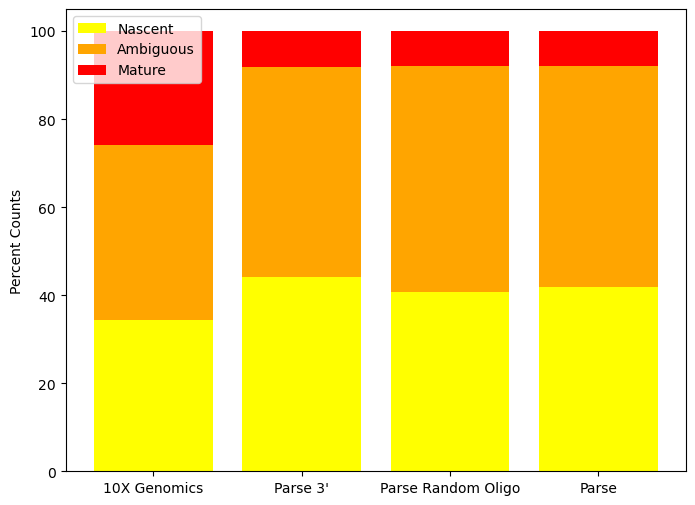

In [7]:
plotting.plot_nascent_mature_ratios(raw_datasets)

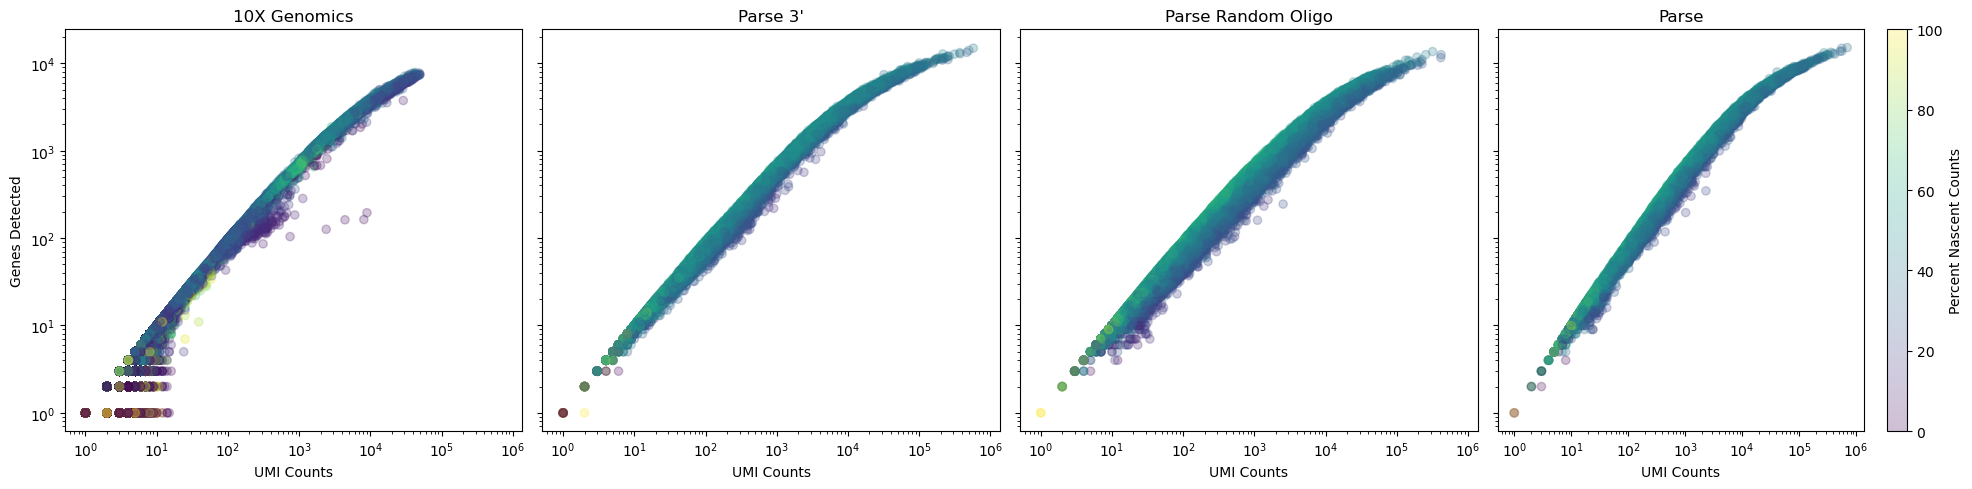

In [8]:
plotting.scatter_reads(raw_datasets)

In [9]:
gene_info = plotting.query_ensembl(PROJECT_DIR, index_dir=INDEX_DIR, species=SPECIES, overwrite=True)

In [10]:
for data in raw_datasets:
    plotting.add_cell_metrics(data, gene_info)

/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.


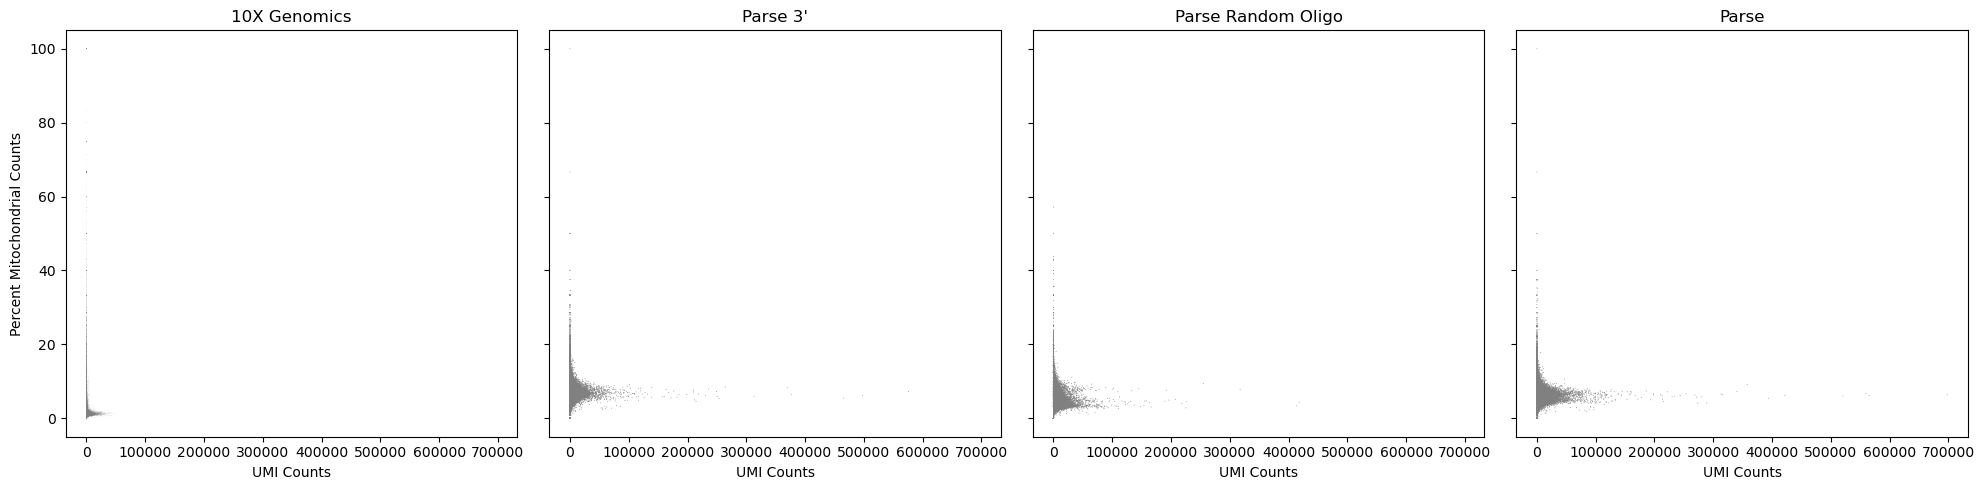

In [11]:
plotting.mito_scatter(raw_datasets)

13,040 cells passed the 1000 UMI threshold for 10X Genomics
Applied CPM normalization and log1p transformation to the filtered data.
32,608 cells passed the 400 UMI threshold for Parse 3'
Applied CPM normalization and log1p transformation to the filtered data.
30,244 cells passed the 400 UMI threshold for Parse Random Oligo
Applied CPM normalization and log1p transformation to the filtered data.
34,073 cells passed the 400 UMI threshold for Parse
Applied CPM normalization and log1p transformation to the filtered data.


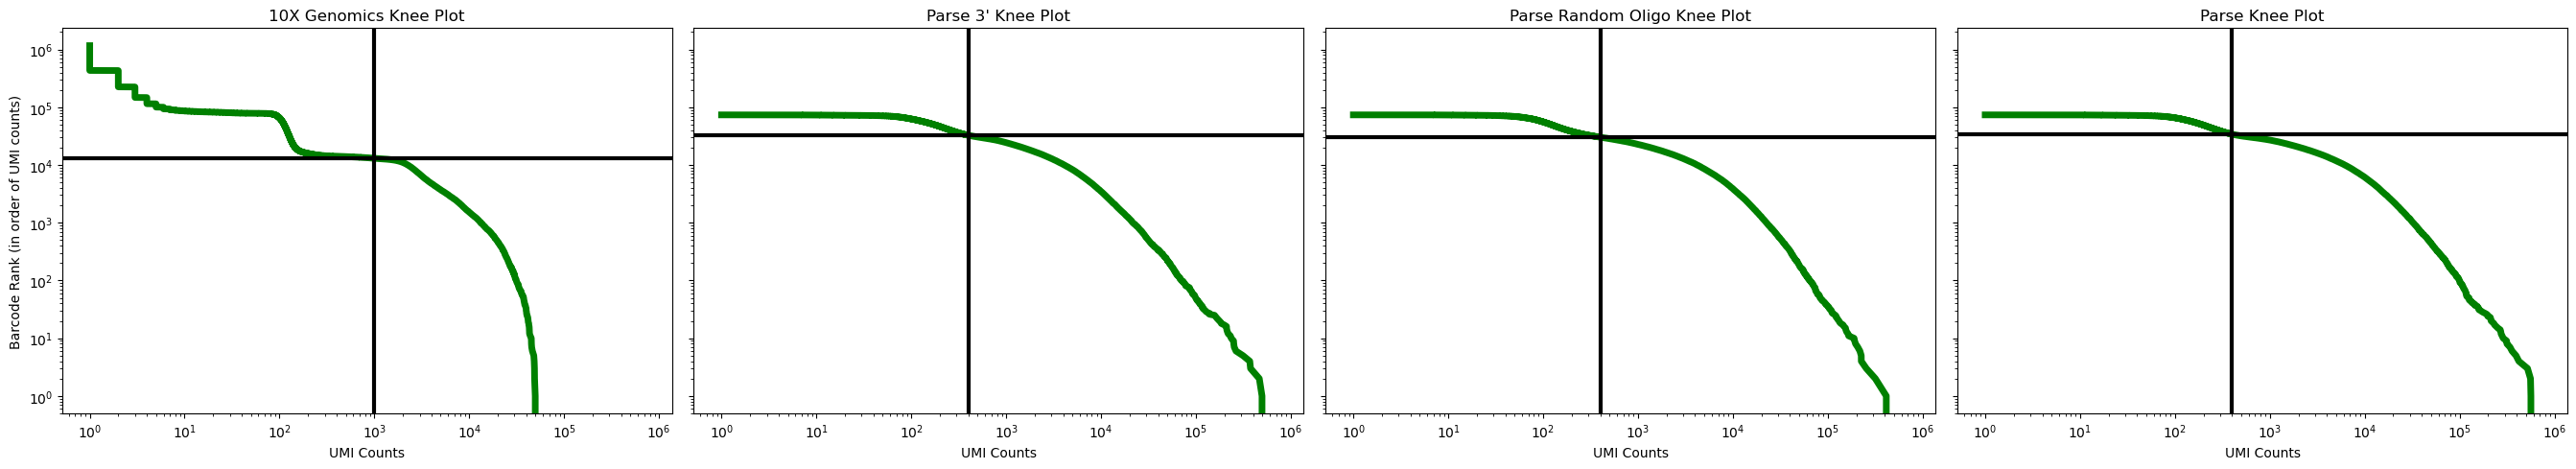

In [12]:
datasets = plotting.knee_plot(raw_datasets, cutoffs=CUTOFFS, transform=LOGCPM_TRANSFORM)

In [13]:
gene_info = plotting.update_gene_info(gene_info, datasets, FULL_GENE_INFO_PATH)

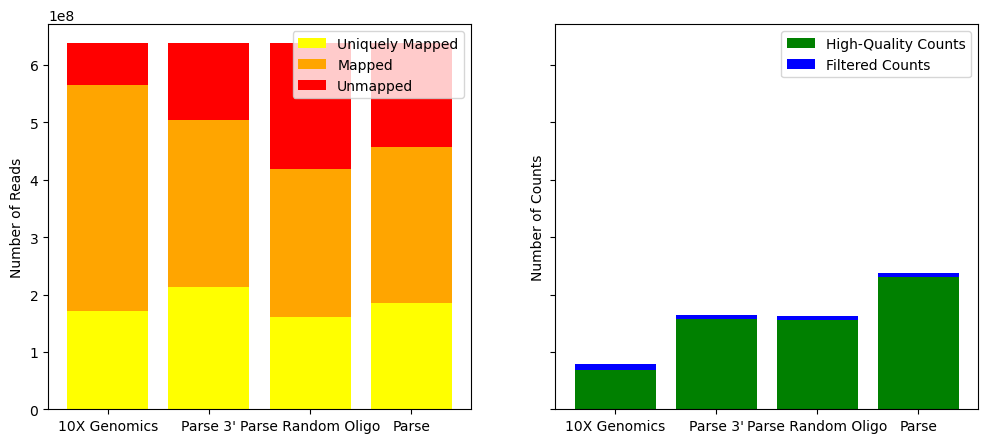

In [14]:
plotting.plot_filtering_metrics(datasets)

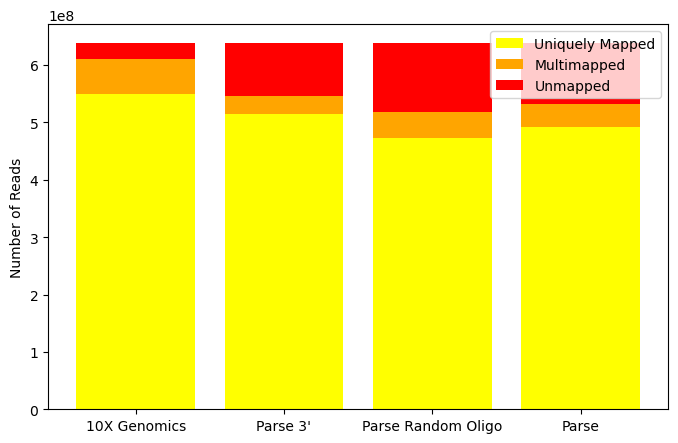

In [15]:
plotting.plot_filtering_metrics_star(datasets)

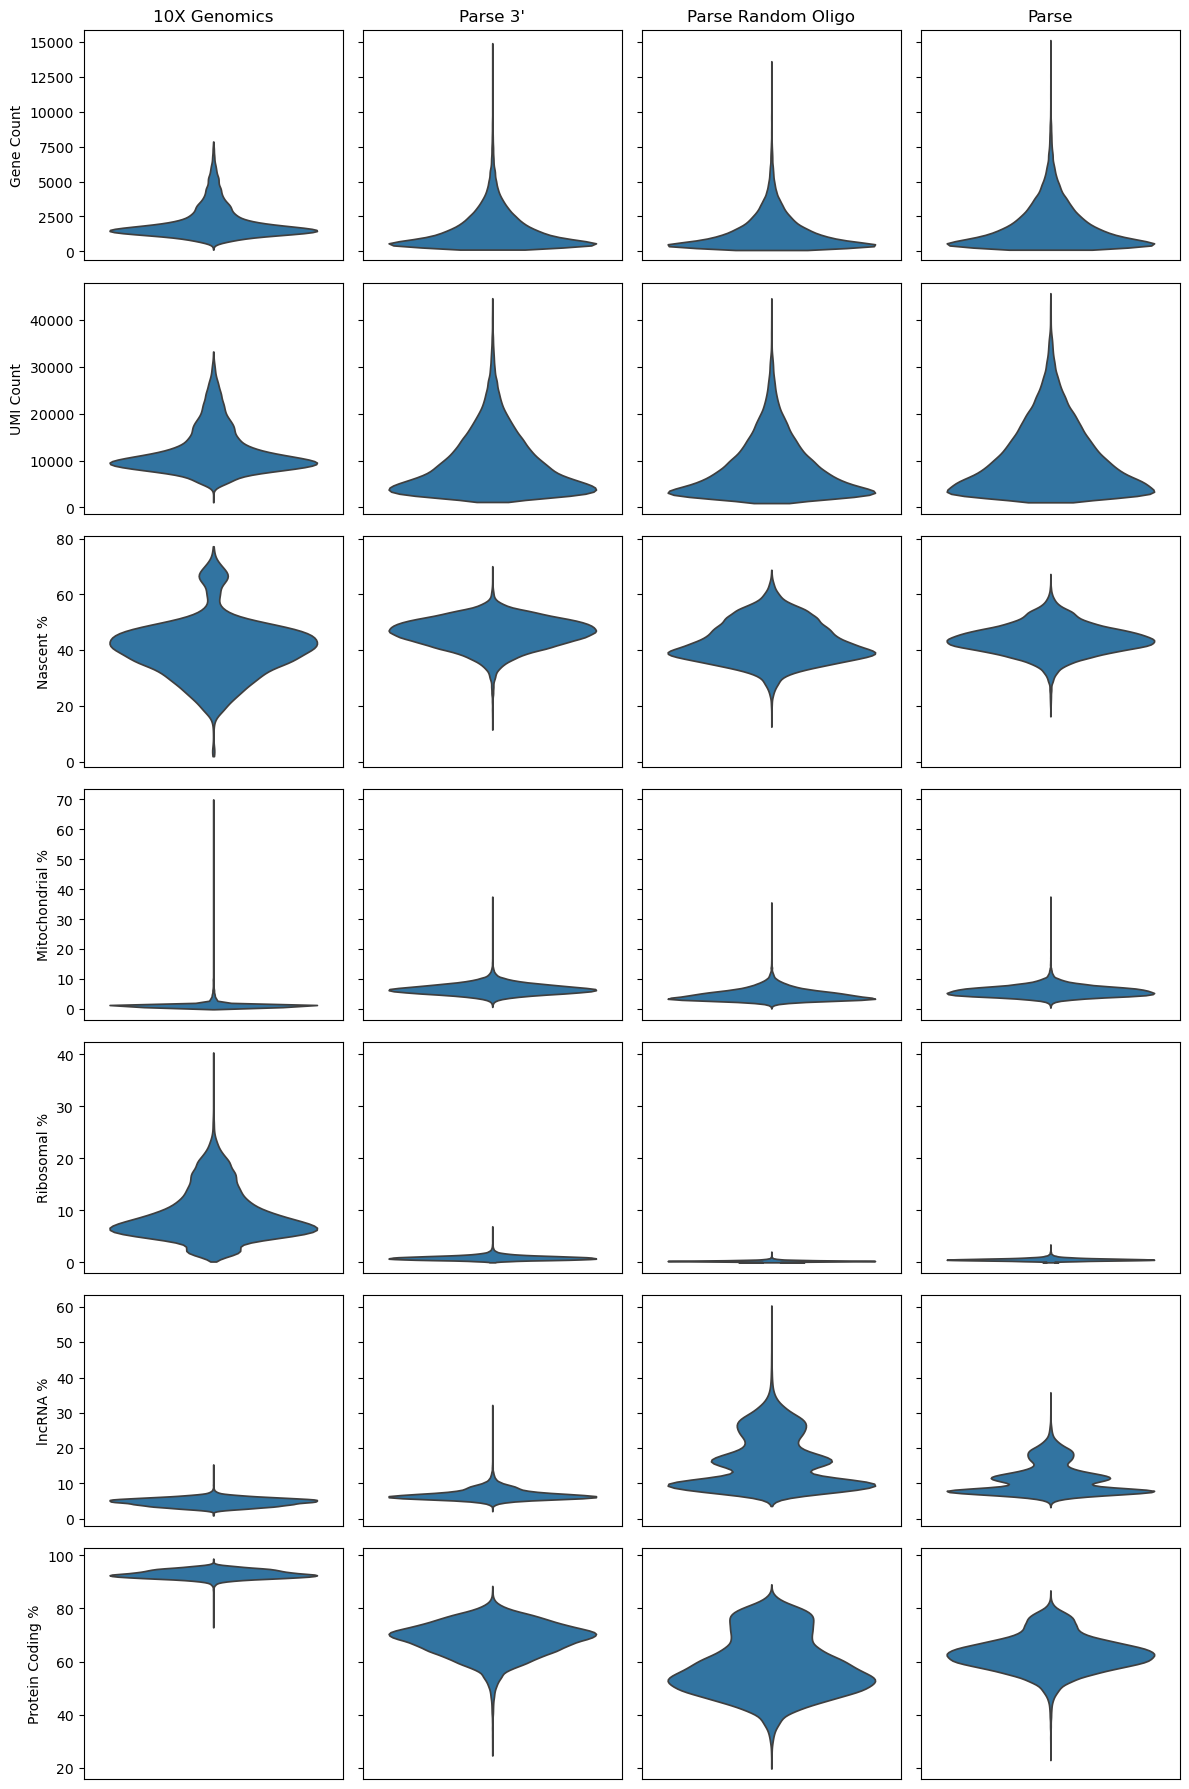

In [16]:
groups = ['n_genes', 'n_counts', 'percent_nascent', 'percent_mito', 'percent_ribo', 'percent_lnc', 'percent_pc']
group_names = ['Gene Count', 'UMI Count', 'Nascent %', 'Mitochondrial %', 'Ribosomal %', 'lncRNA %', 'Protein Coding %']

plotting.plot_cell_metrics(datasets, groups=groups, group_names=group_names)

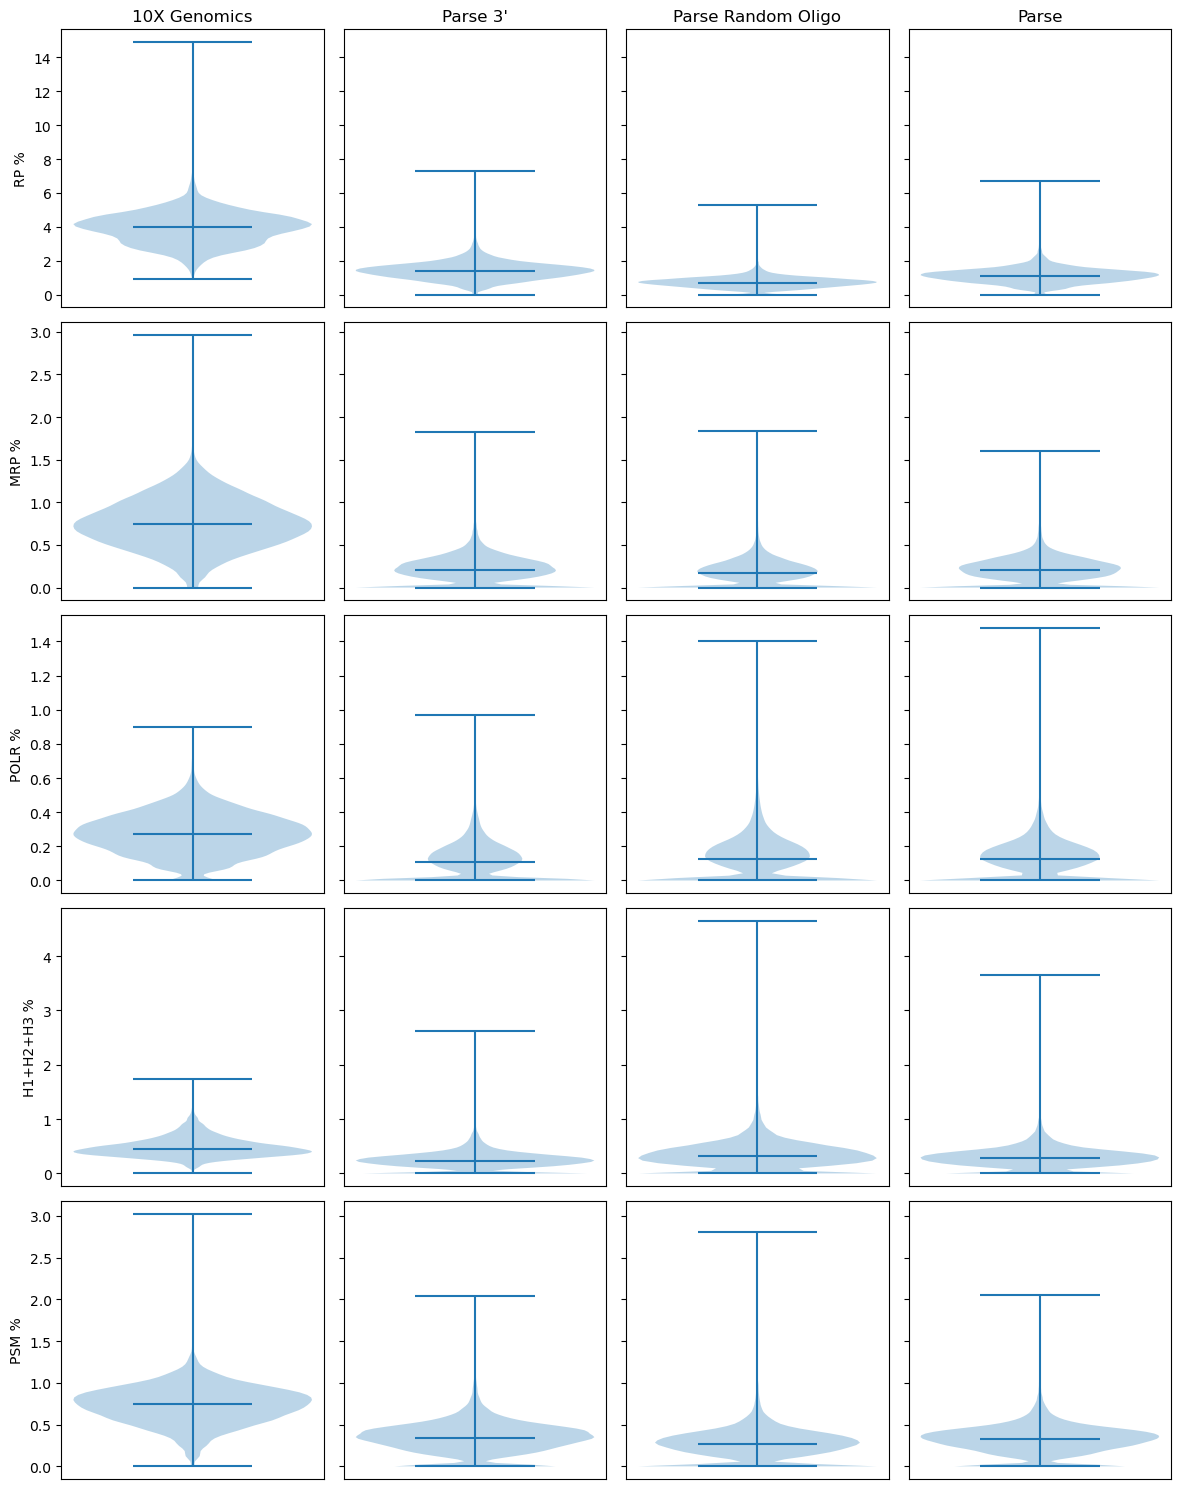

In [17]:
# Transcritptional Gene Family Percentages
plotting.plot_gene_family_percentages(datasets, gene_families=["RP", "MRP", "POLR", "H1+H2+H3", "PSM"])

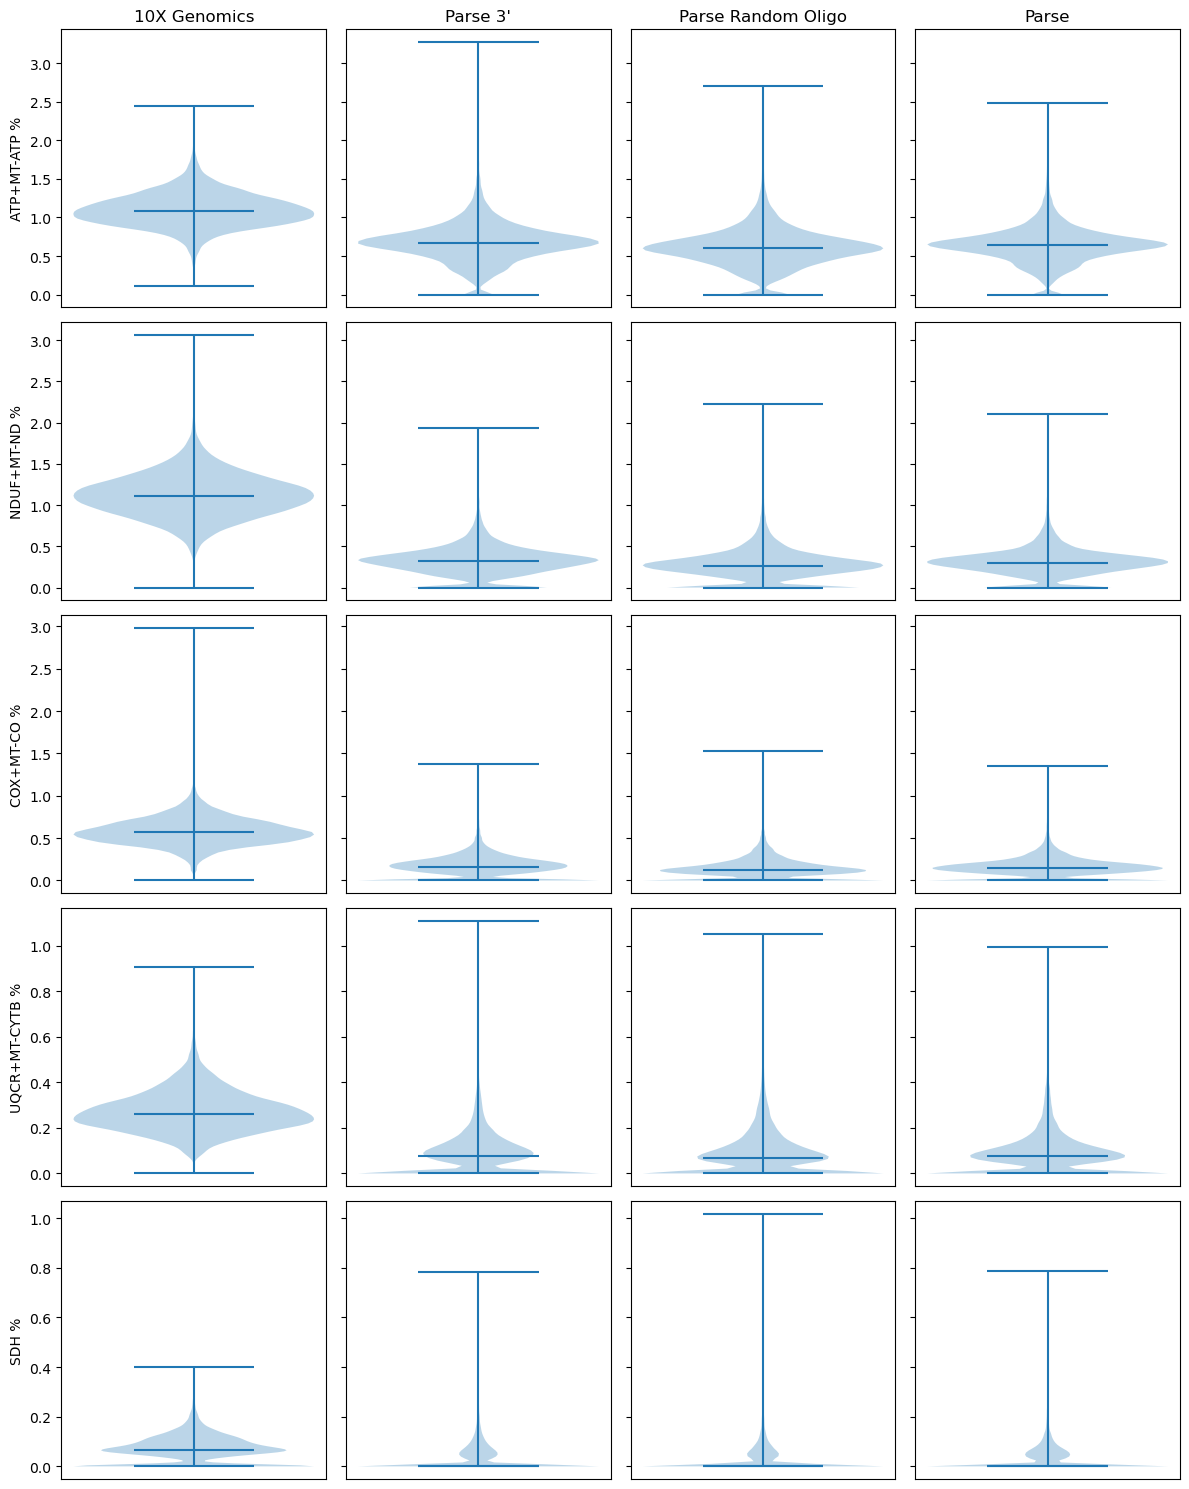

In [18]:
# OXPHOS Gene Family Percentages
plotting.plot_gene_family_percentages(datasets, gene_families=["ATP+MT-ATP", "NDUF+MT-ND", "COX+MT-CO", "UQCR+MT-CYTB", "SDH"])

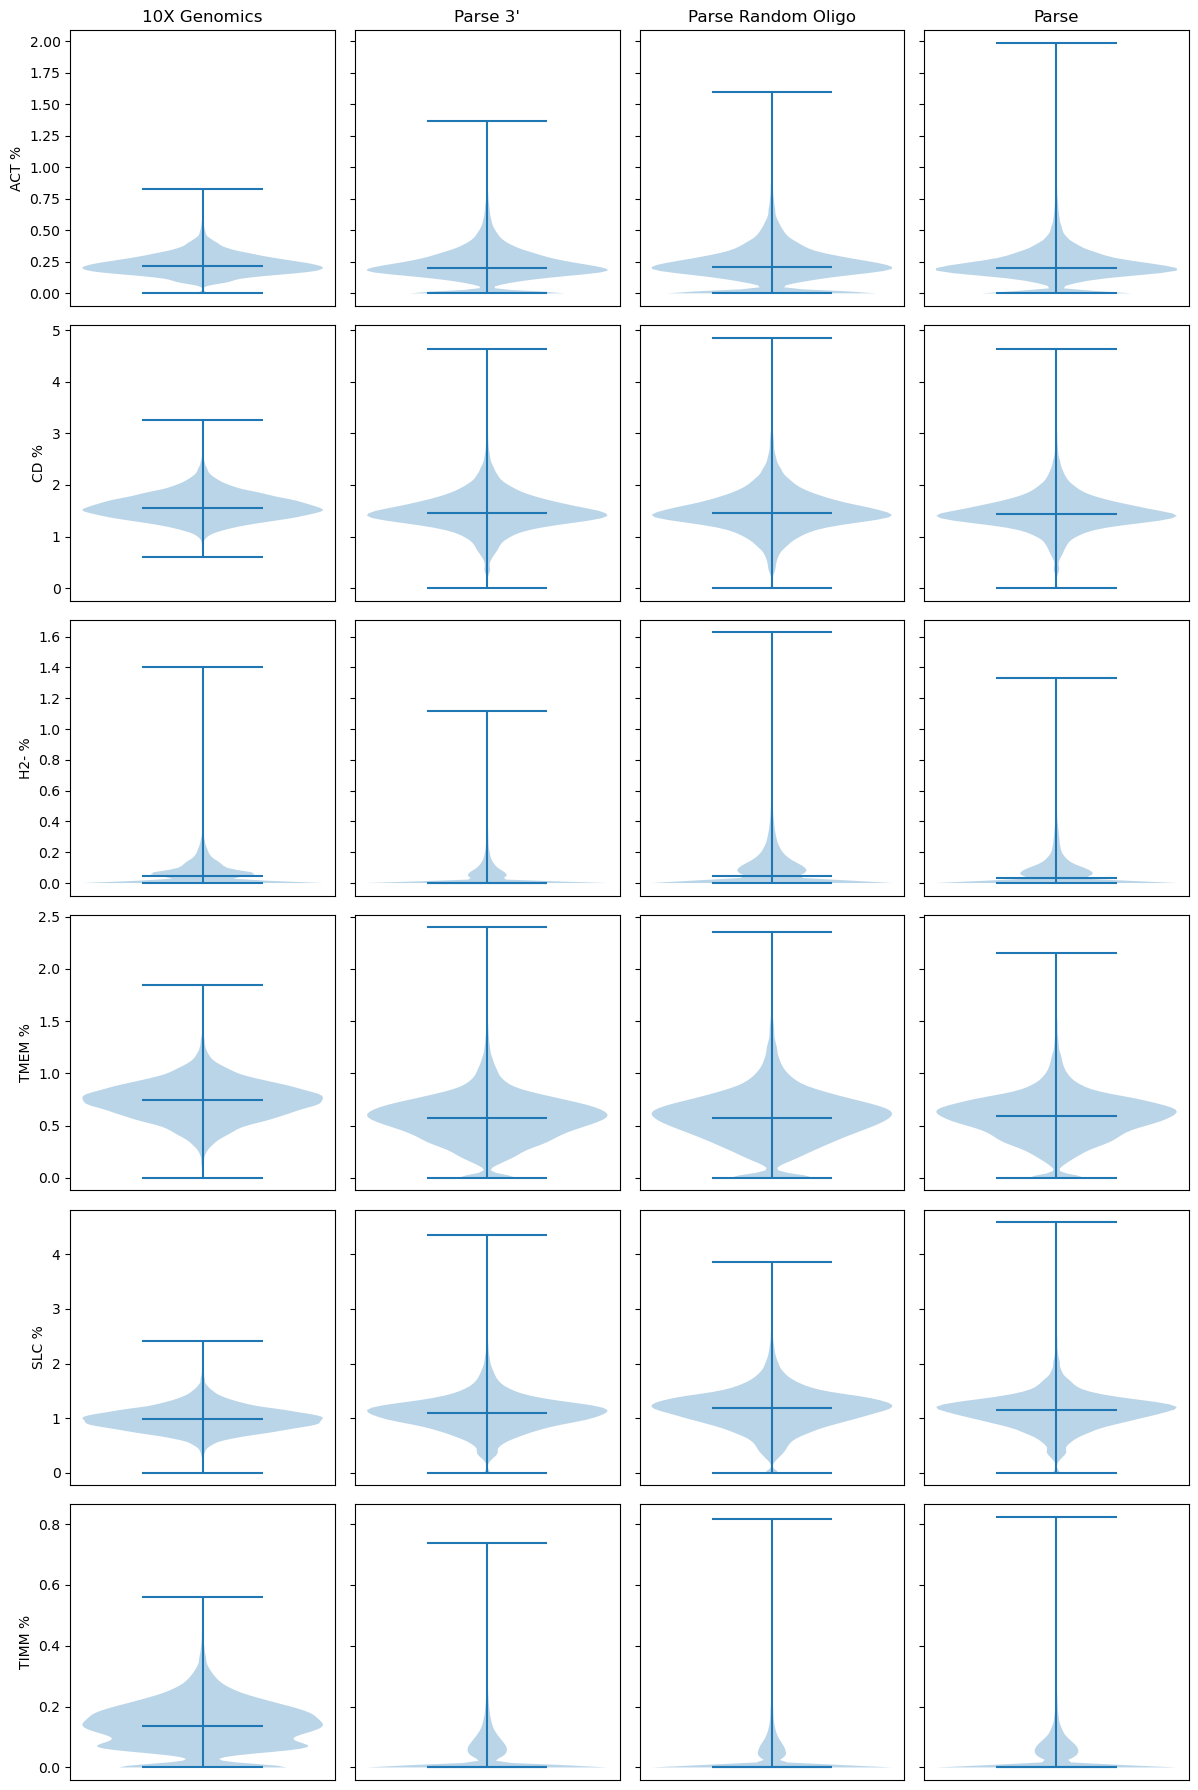

In [19]:
# cell suface and transmembrane protein gene family percentages
plotting.plot_gene_family_percentages(datasets, gene_families=["ACT", "CD", "H2-", "TMEM", "SLC", "TIMM"])

# Read/Gene Comparisons

In [20]:
# Pan-leukocyte anchor
pan_leukocyte = ["Ptprc"]

# Early thymic progenitor & T-lineage commitment (ETP / DN1–DN2)
early_progenitor_commitment = ["Kit", "Cd44", "Bcl11b", "Tcf7", "Gata3"]

# Rearrangement & β-selection (DN3–DN4)
rearrangement_beta_selection = ["Il2ra", "Rag1", "Rag2", "Ptcra", "Dntt"]

# Proliferation
proliferation = ["Mki67"]

# DP identity & TCR/CD3
dp_identity = ["Cd4", "Cd8a", "Cd8b1", "Cd24a", "Cd3e", "Cd3d", "Cd3g"]

# Positive selection & TCR signal strength
positive_selection_signal = ["Themis", "Cd69", "Cd5", "Cd28", "Nr4a1"]

# CD4 vs CD8 lineage commitment
lineage_commitment = ["Zbtb7b", "Runx3"]

# SP maturation & thymic egress
sp_maturation_egress = ["Ccr9", "Ccr7", "Sell", "Klf2", "S1pr1"]

# Regulatory T cells
treg = ["Foxp3"]

# Survival / negative-selection axis
survival_negative_selection = ["Bcl2", "Bcl2l11"]

# γδ / innate-like lineage
gd_innate = ["Zbtb16"]

# Stromal & myeloid contamination flags (QC) — NOT thymocyte-intrinsic
qc_stromal_myeloid = ["Aire", "Krt5", "Krt8", "Krt18", "Lyz2"] #"Krt14"

thymocyte_markers = {
    "Pan Leukocyte": pan_leukocyte,
    "Early Progenitor Commitment": early_progenitor_commitment,
    "Rearrangement/Beta Selection": rearrangement_beta_selection,
    "Proliferation": proliferation,
    "DP Identity": dp_identity,
    "Positive Selection Signal": positive_selection_signal,
    "Lineage Commitment": lineage_commitment,
    "SP Maturation Egress": sp_maturation_egress,
    "Treg": treg,
    "Survival Negative Selection": survival_negative_selection,
    "GD Innate": gd_innate,
    "Stromal/Myeloid QC": qc_stromal_myeloid,
}

# TCR loci — PREFIXES (match by startswith, not exact)
tcr_loci_prefixes = ["Trav", "Trbv", "Trgv", "Trdv"]

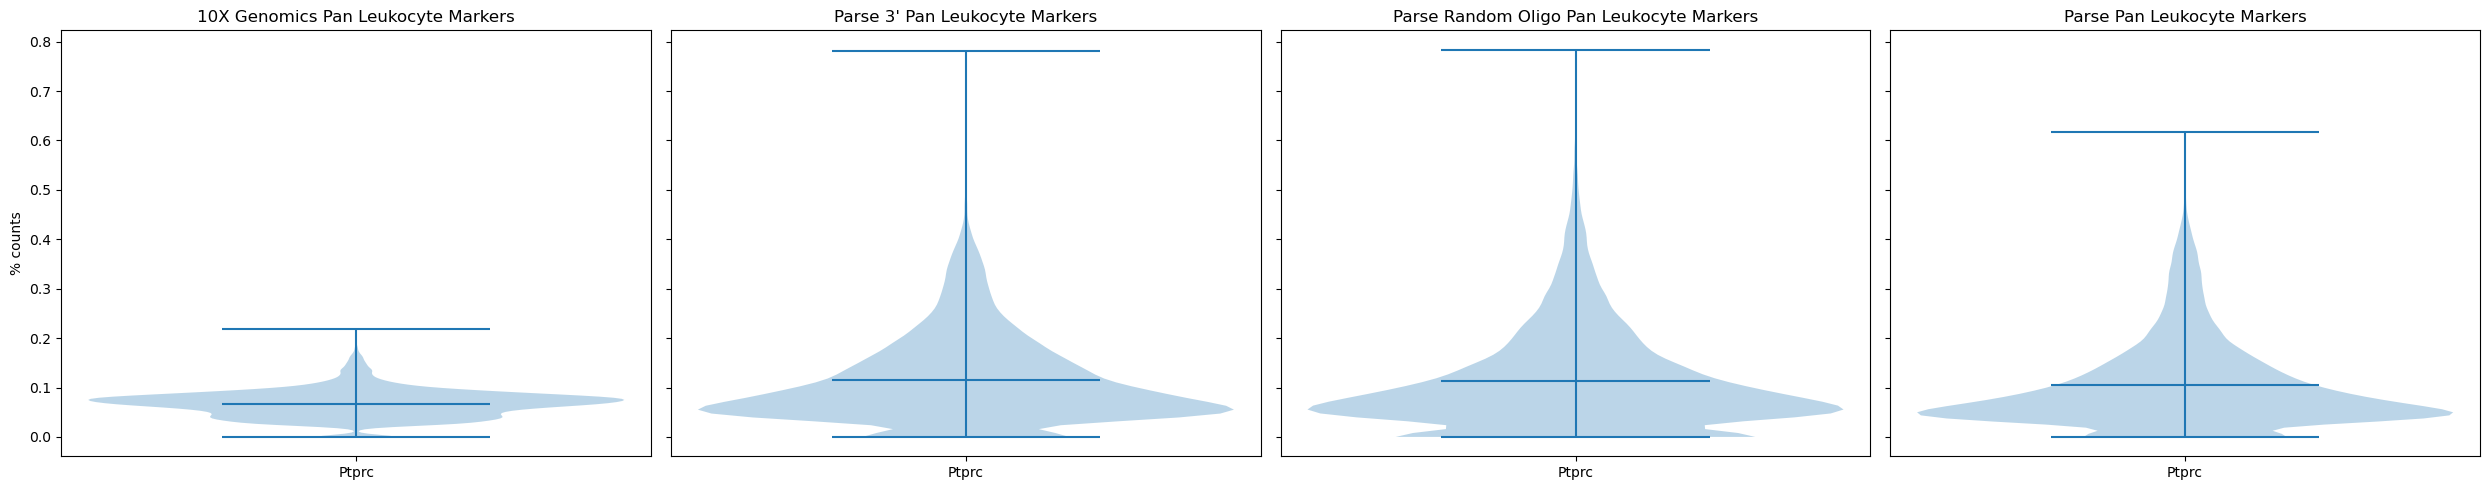

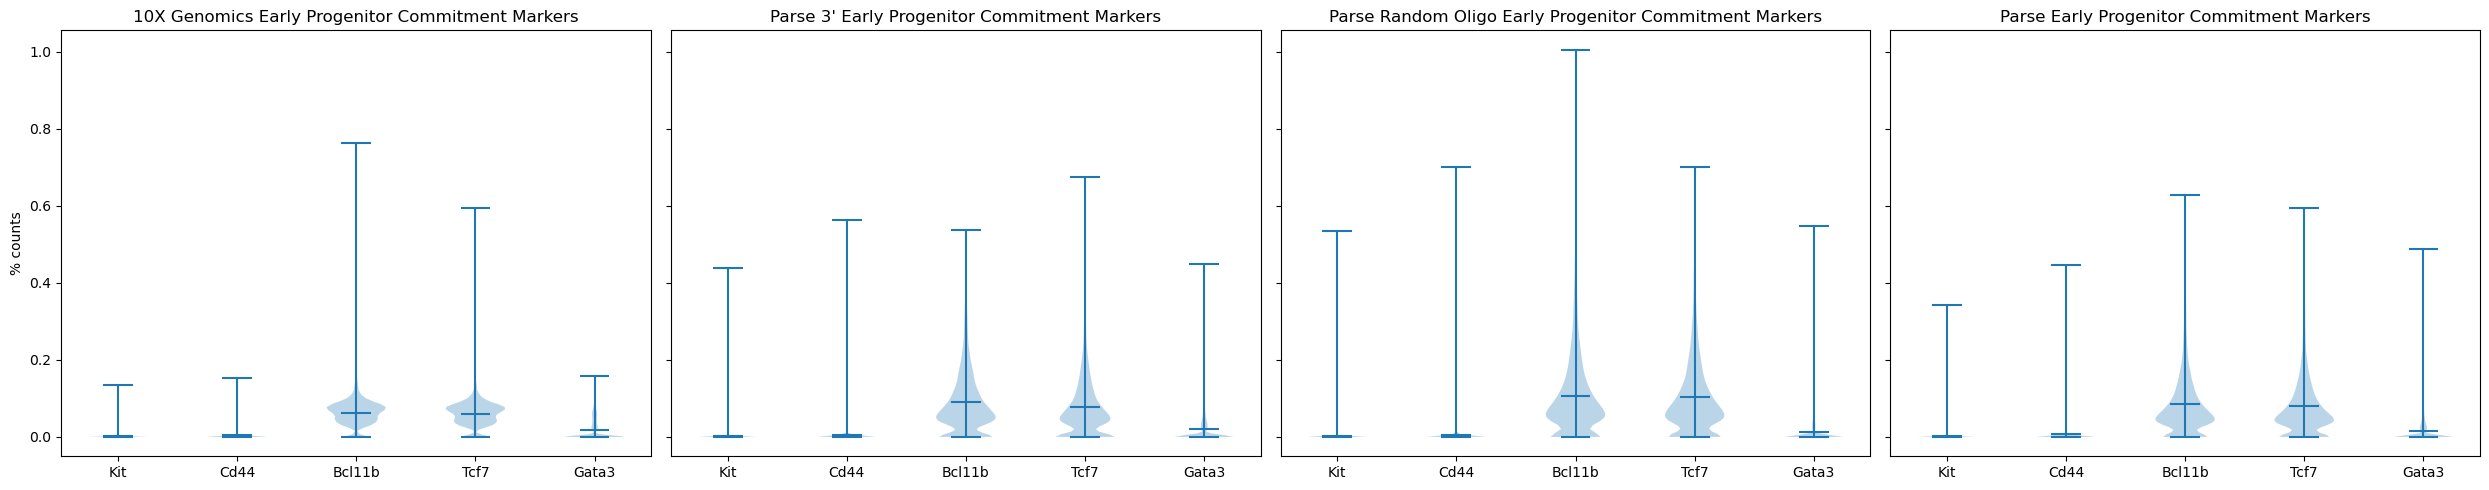

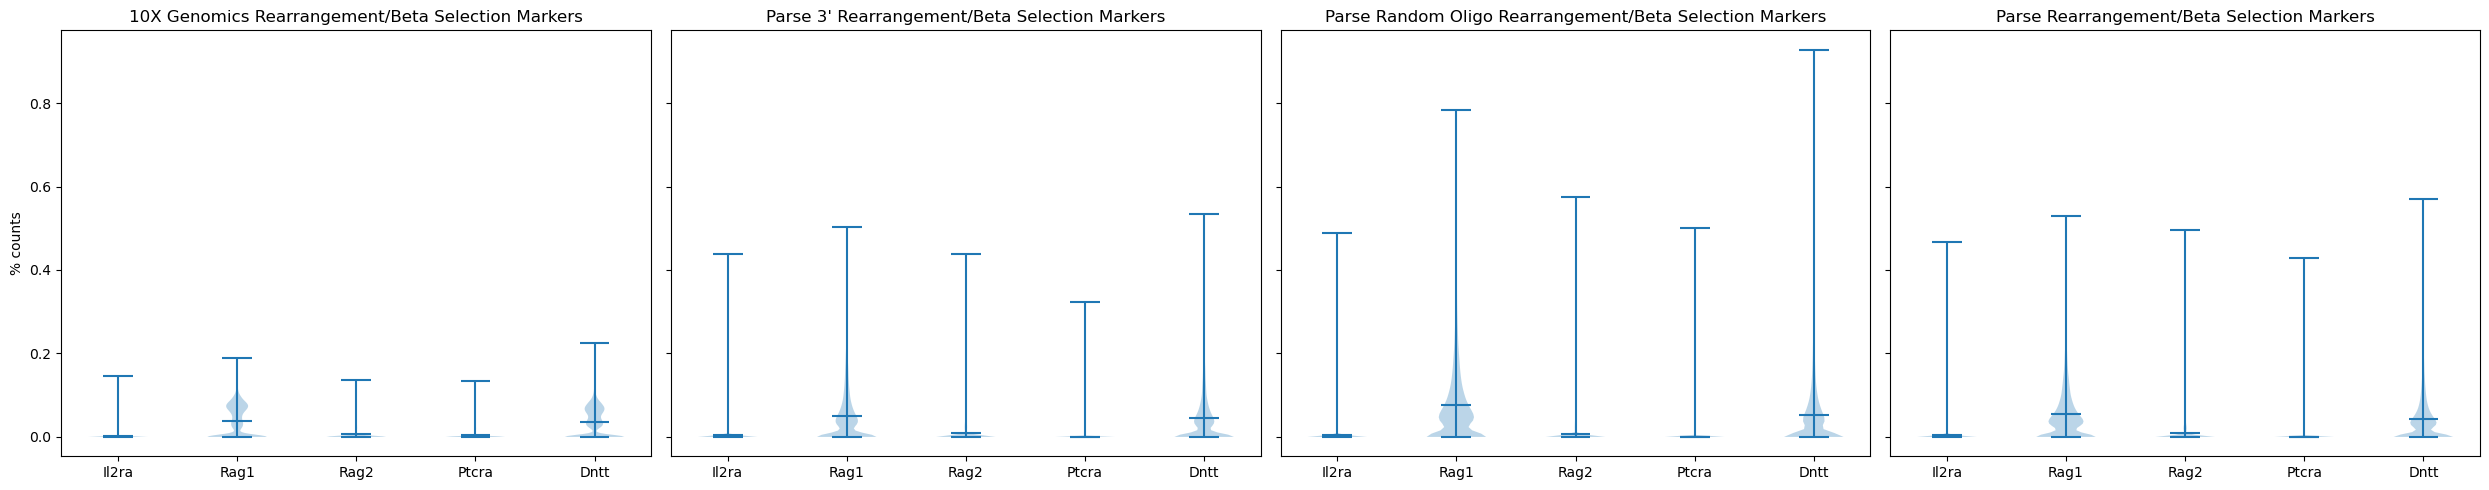

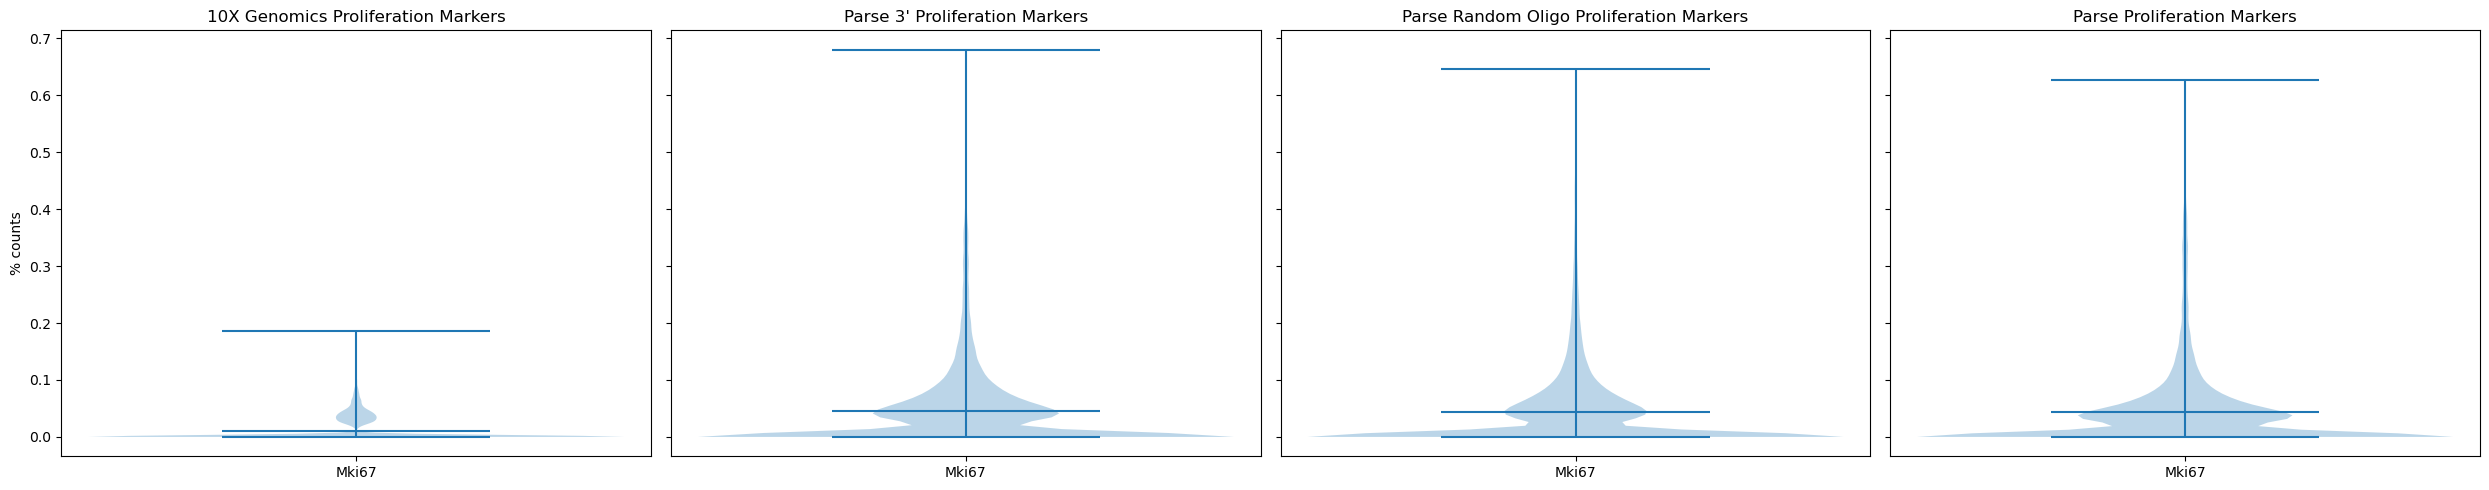

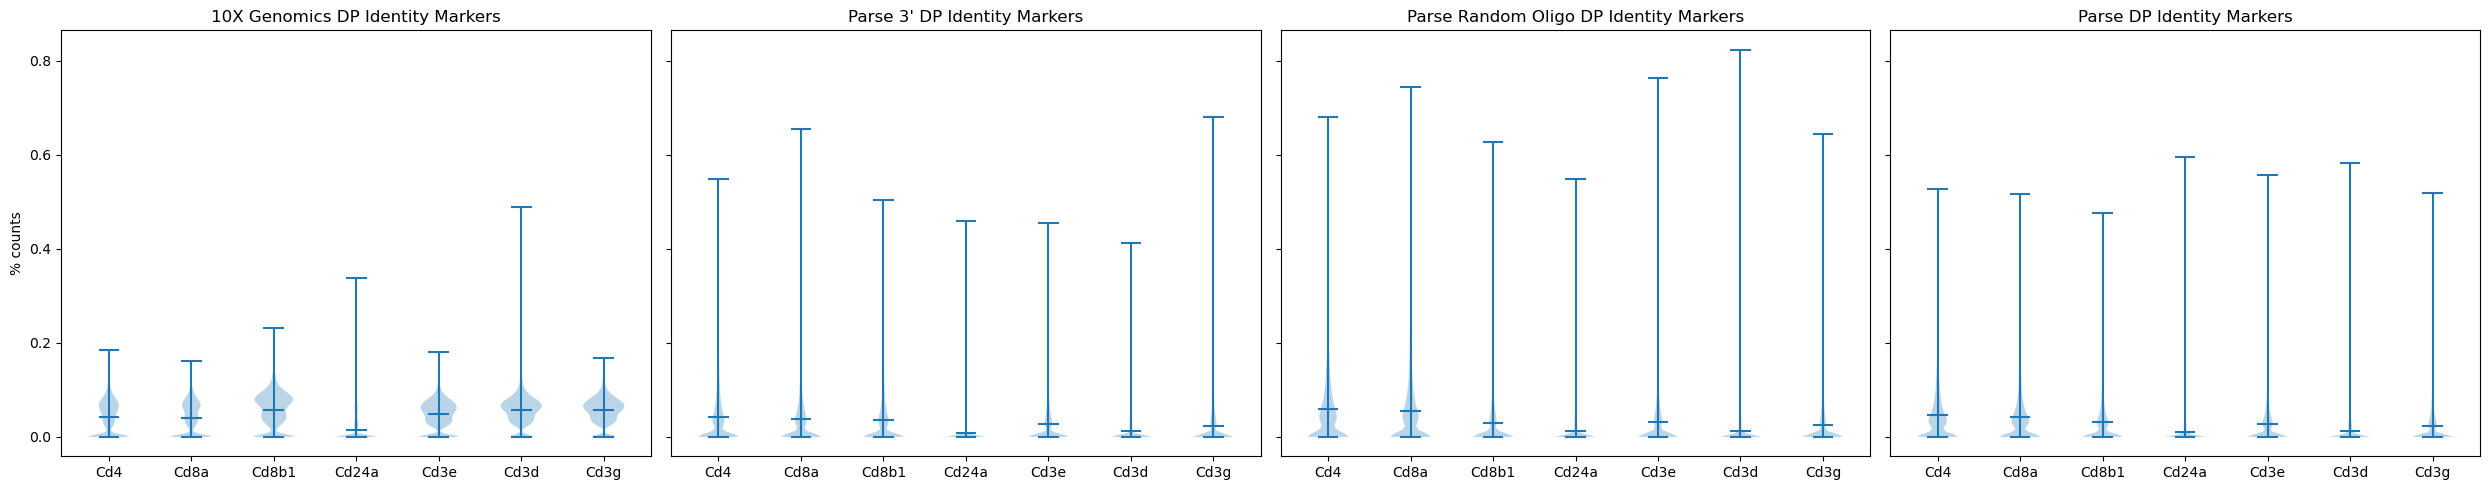

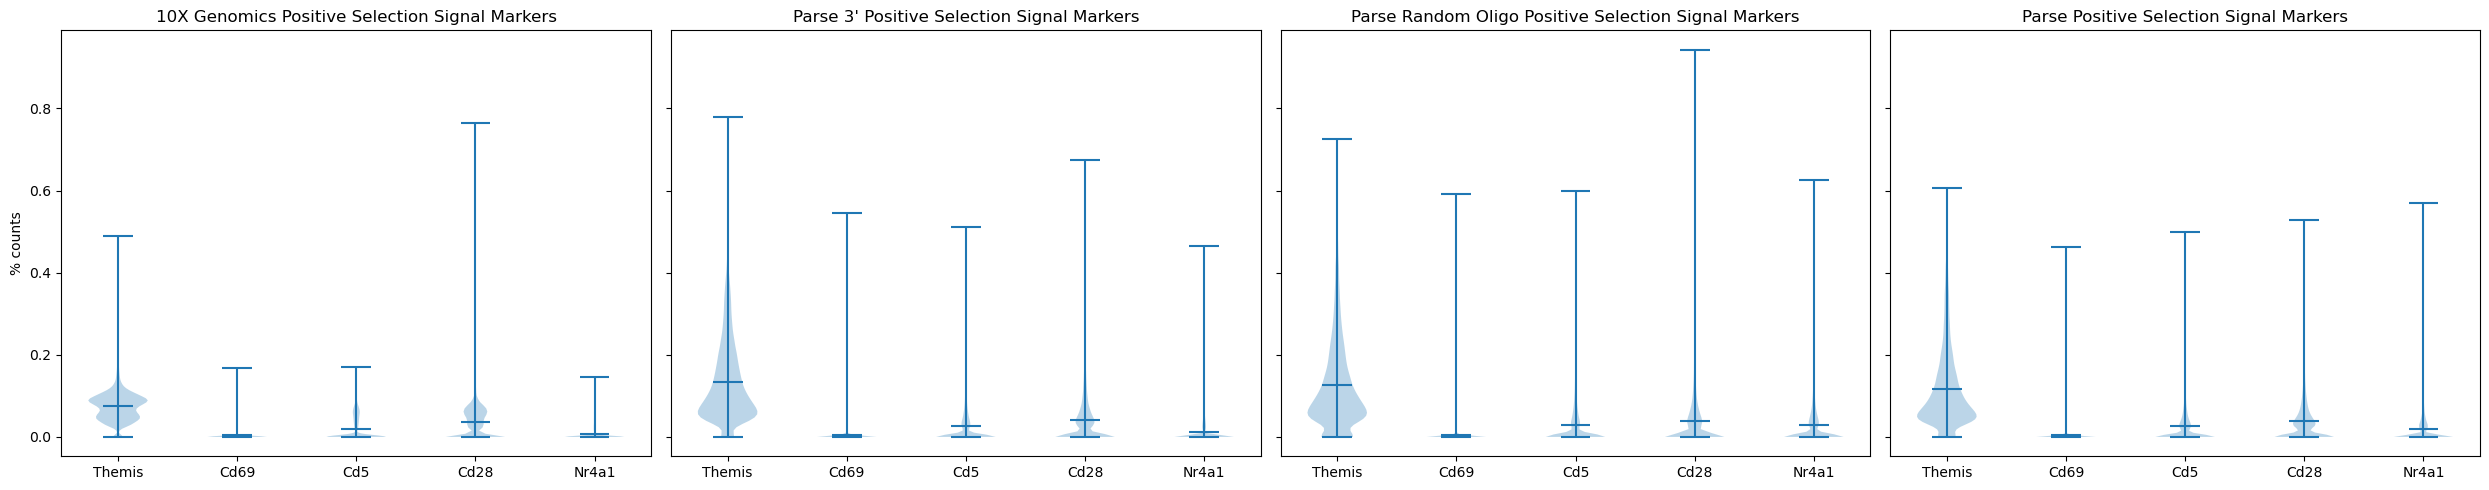

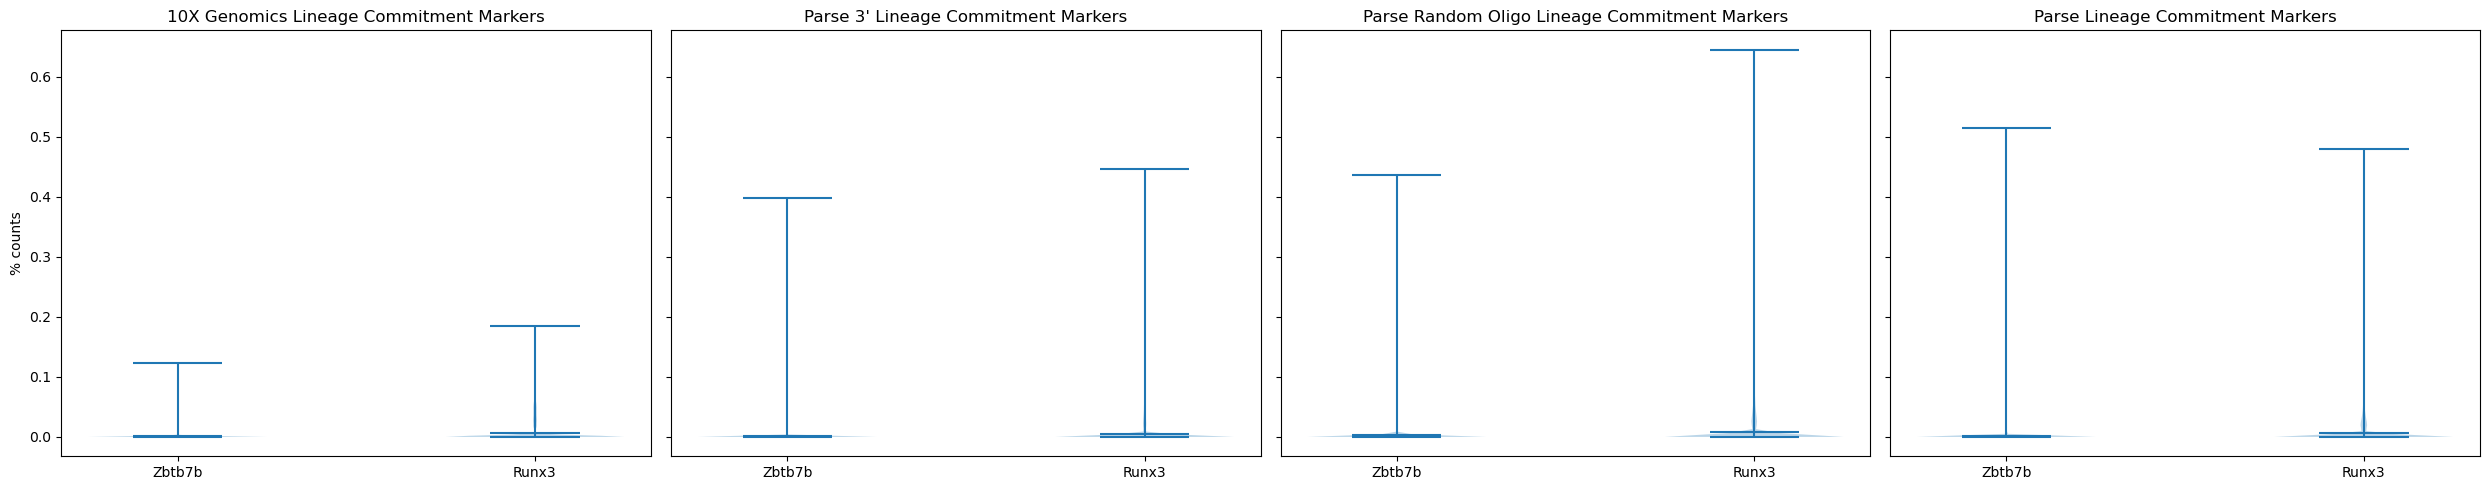

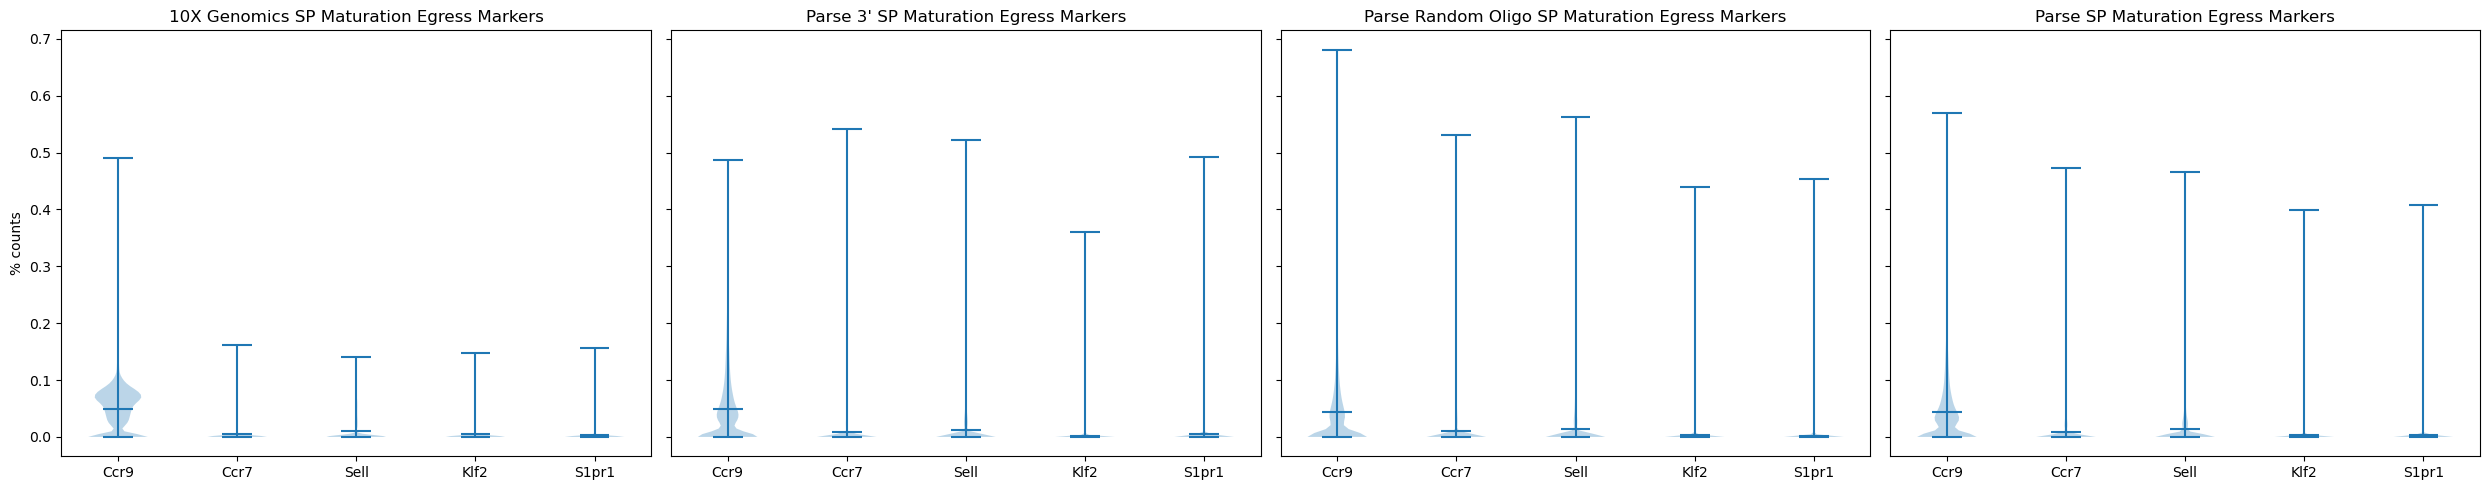

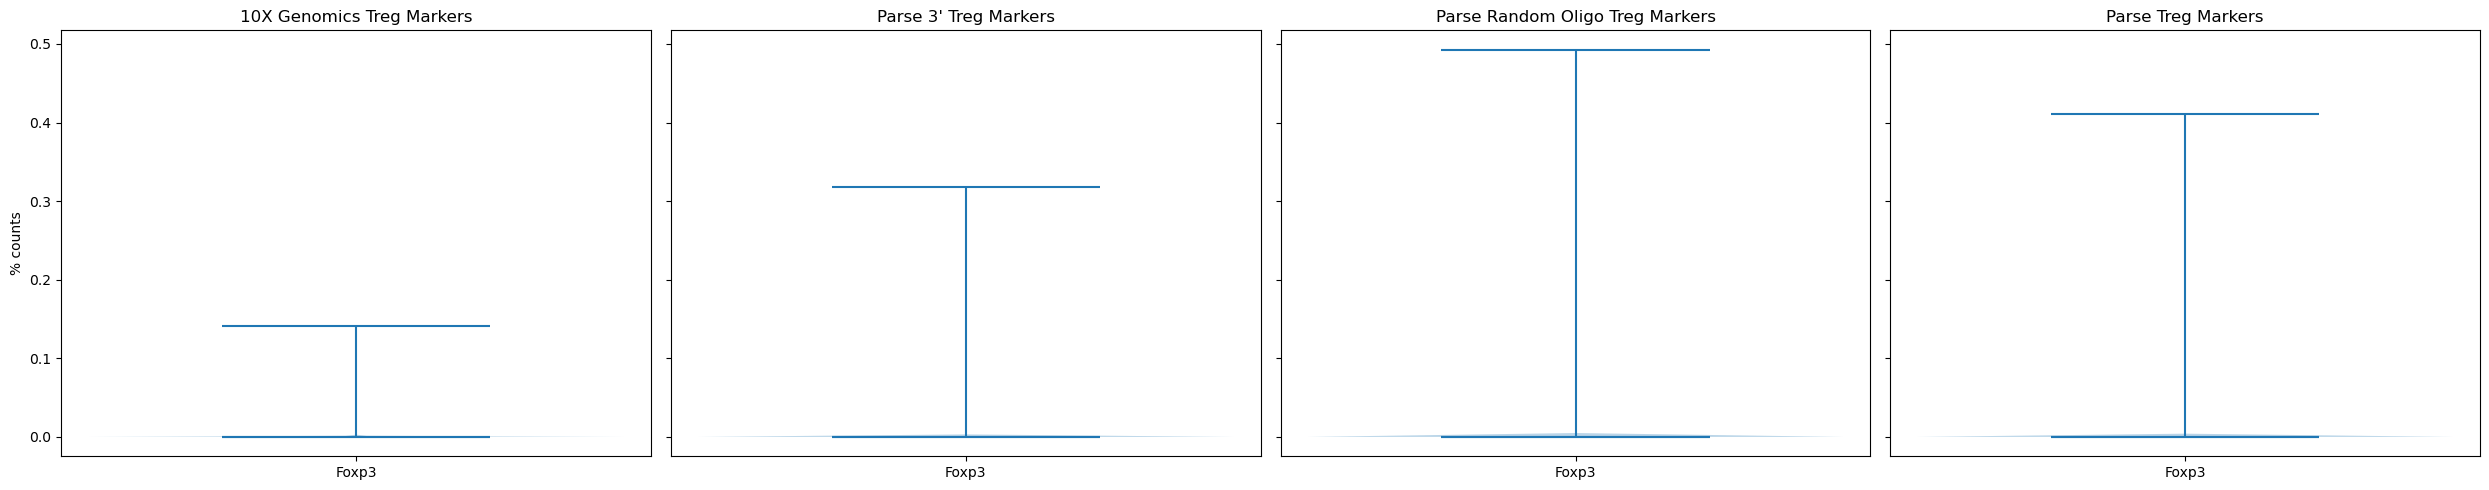

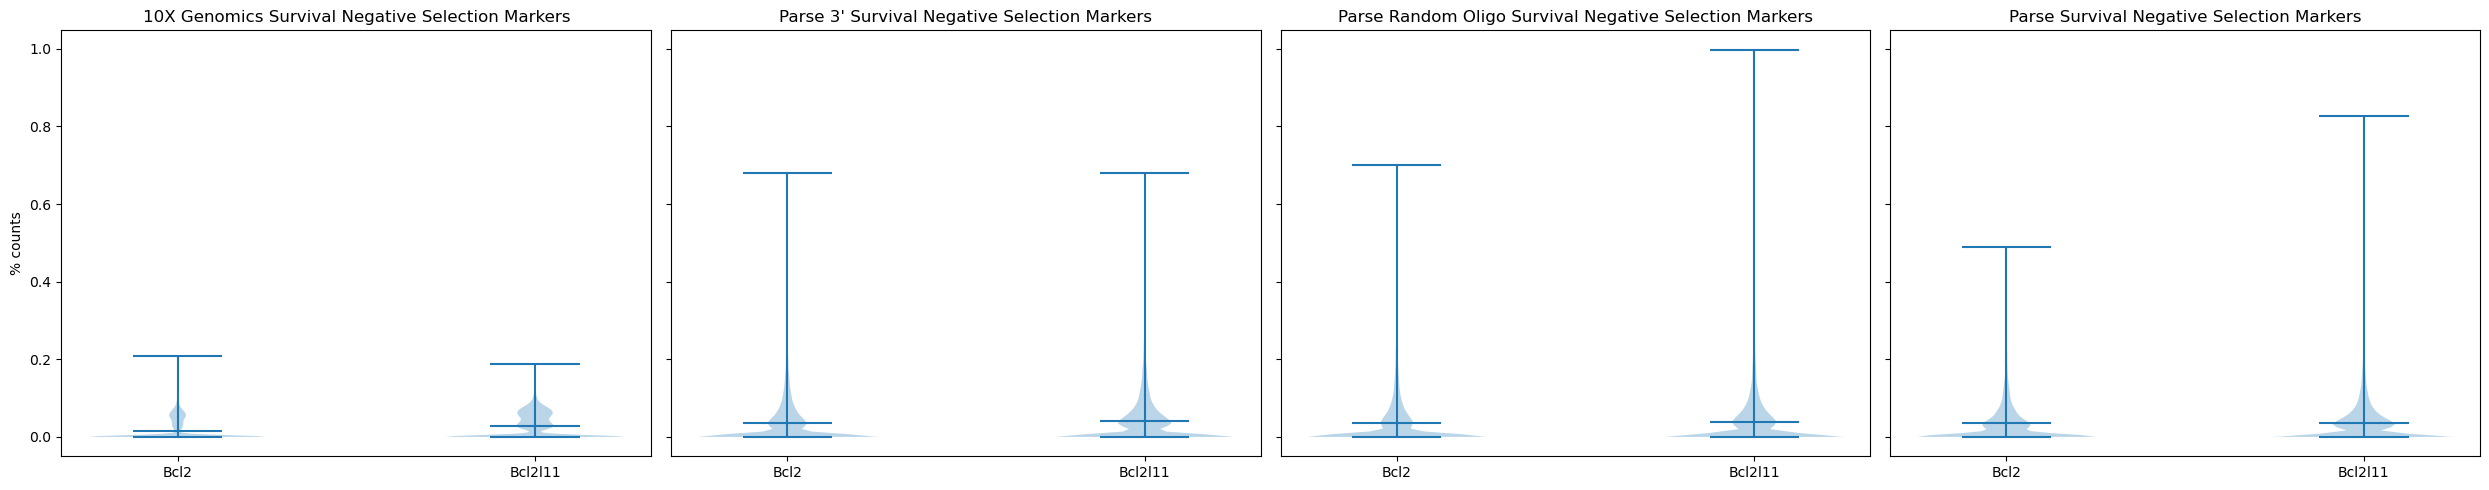

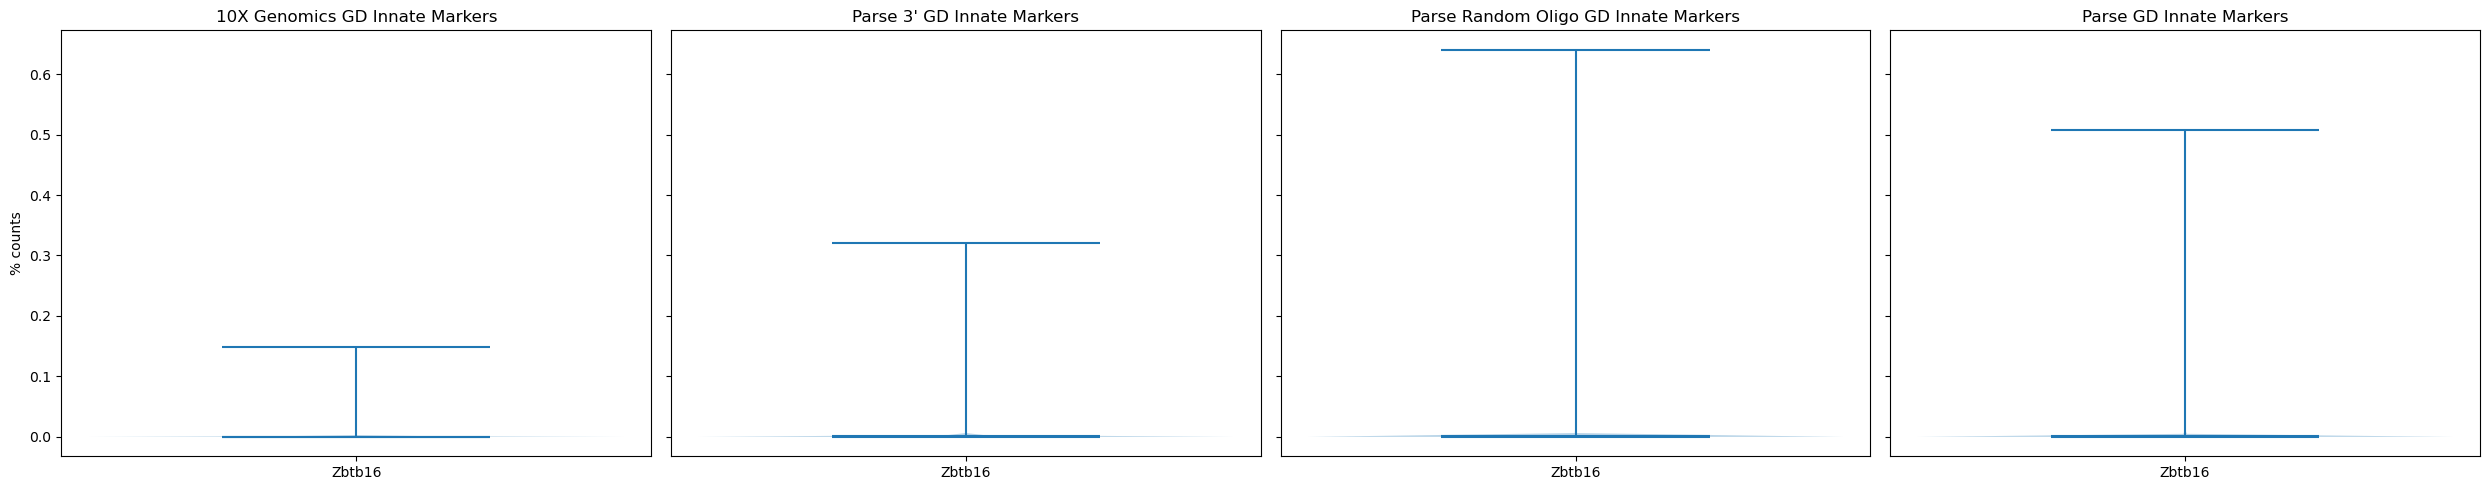

KeyboardInterrupt: 

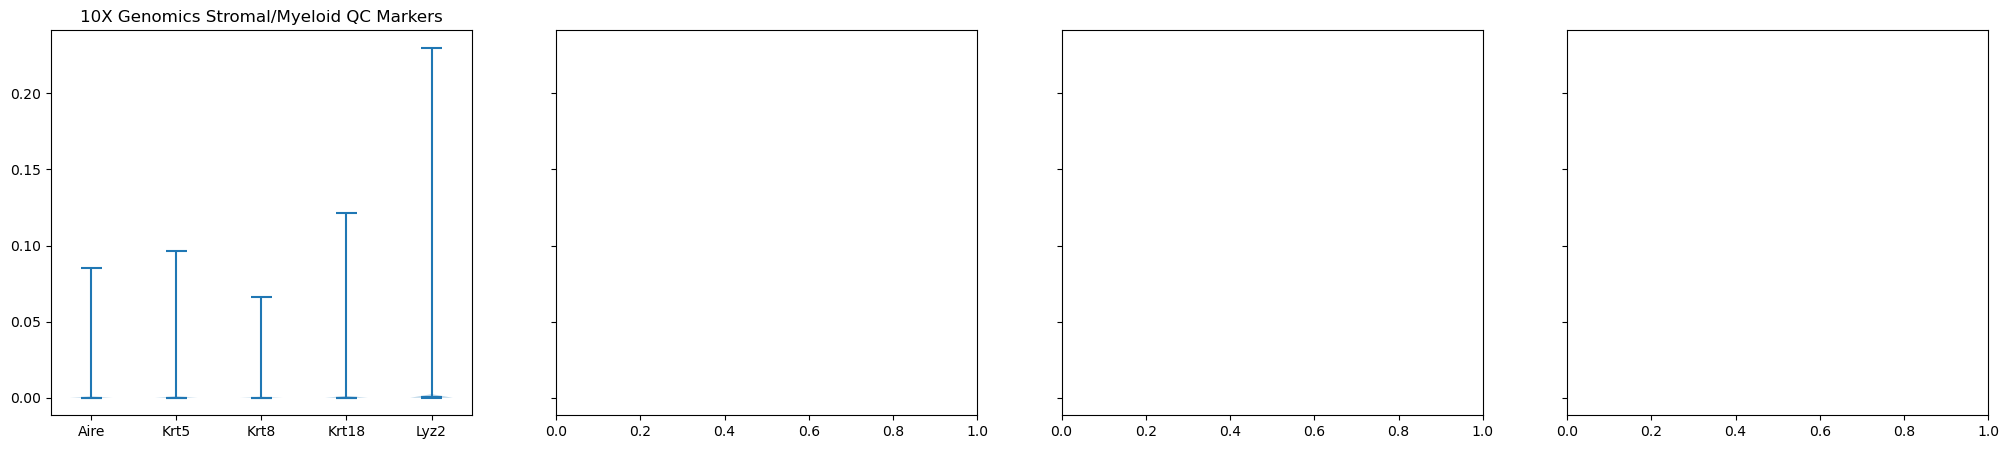

In [21]:
for marker_set_name in thymocyte_markers.keys():
    plotting.marker_genes(datasets, thymocyte_markers[marker_set_name], plot_title=marker_set_name + " Markers")

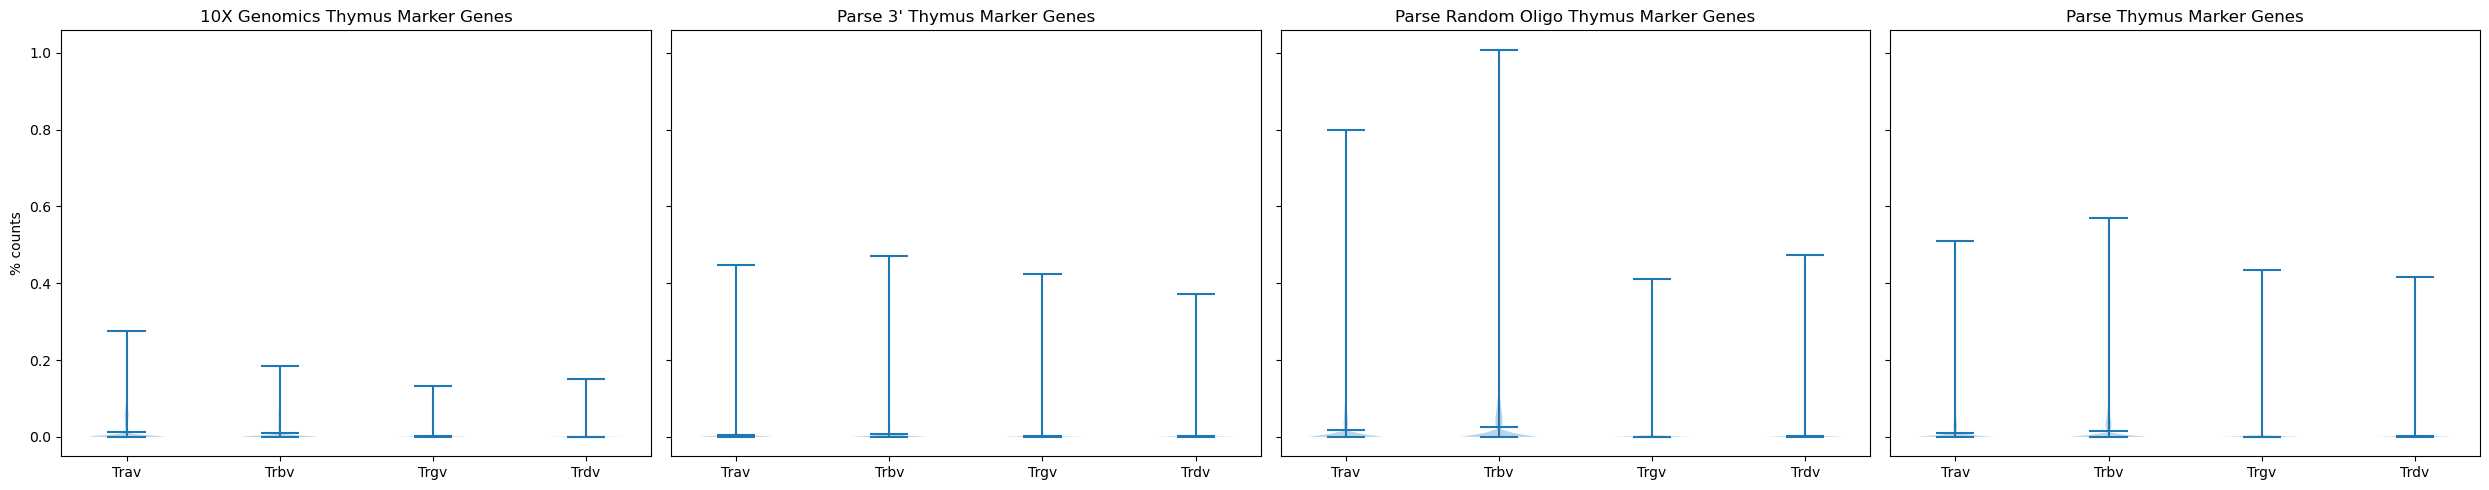

In [ ]:
plotting.collapsed_marker_genes(datasets, tcr_loci_prefixes)

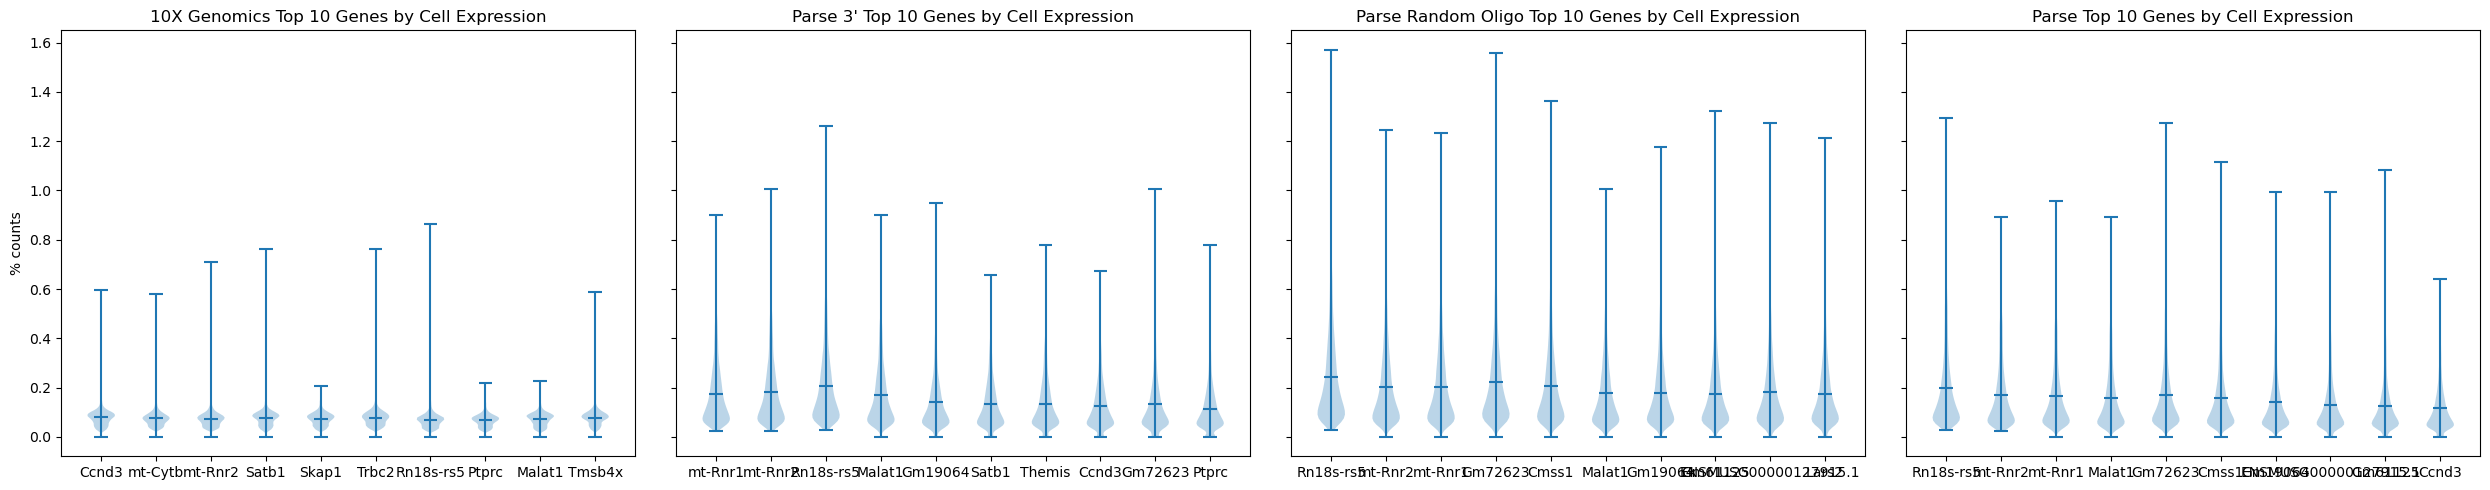

In [ ]:
plotting.top_gene_cell_expression(datasets)

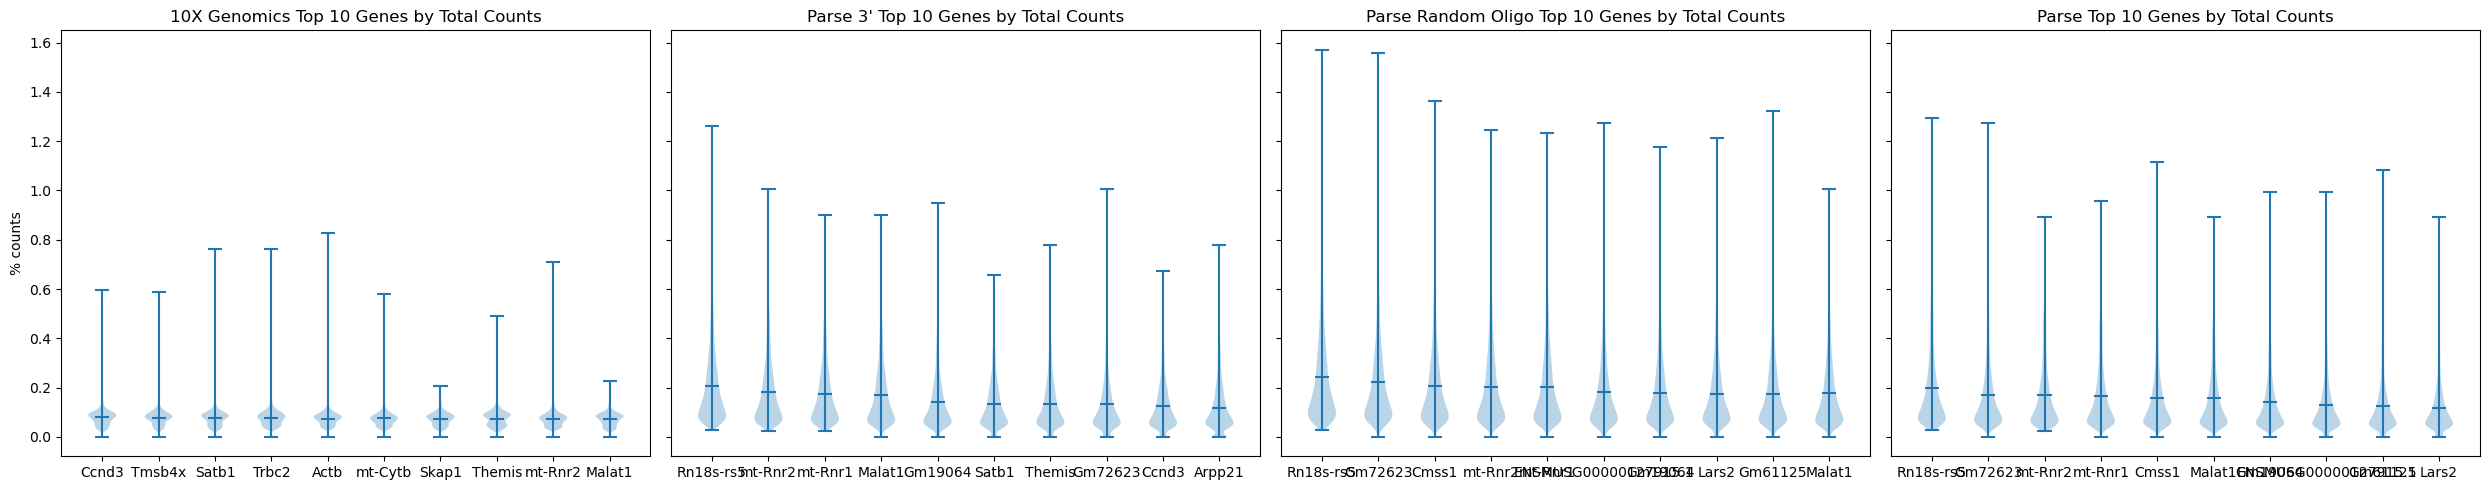

In [ ]:
plotting.top_gene_counts(datasets)

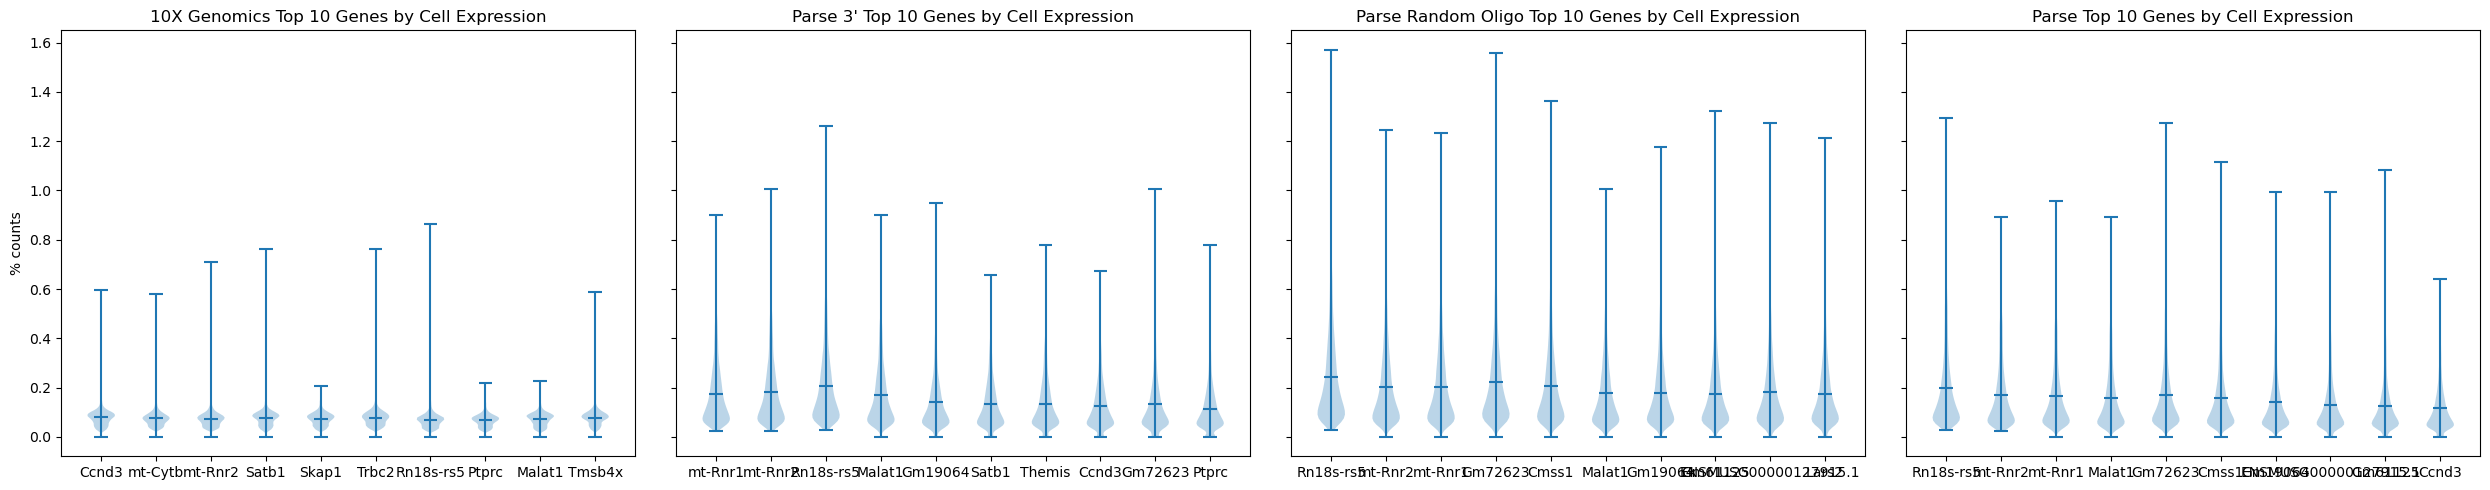

In [ ]:
plotting.top_gene_cell_expression(datasets)

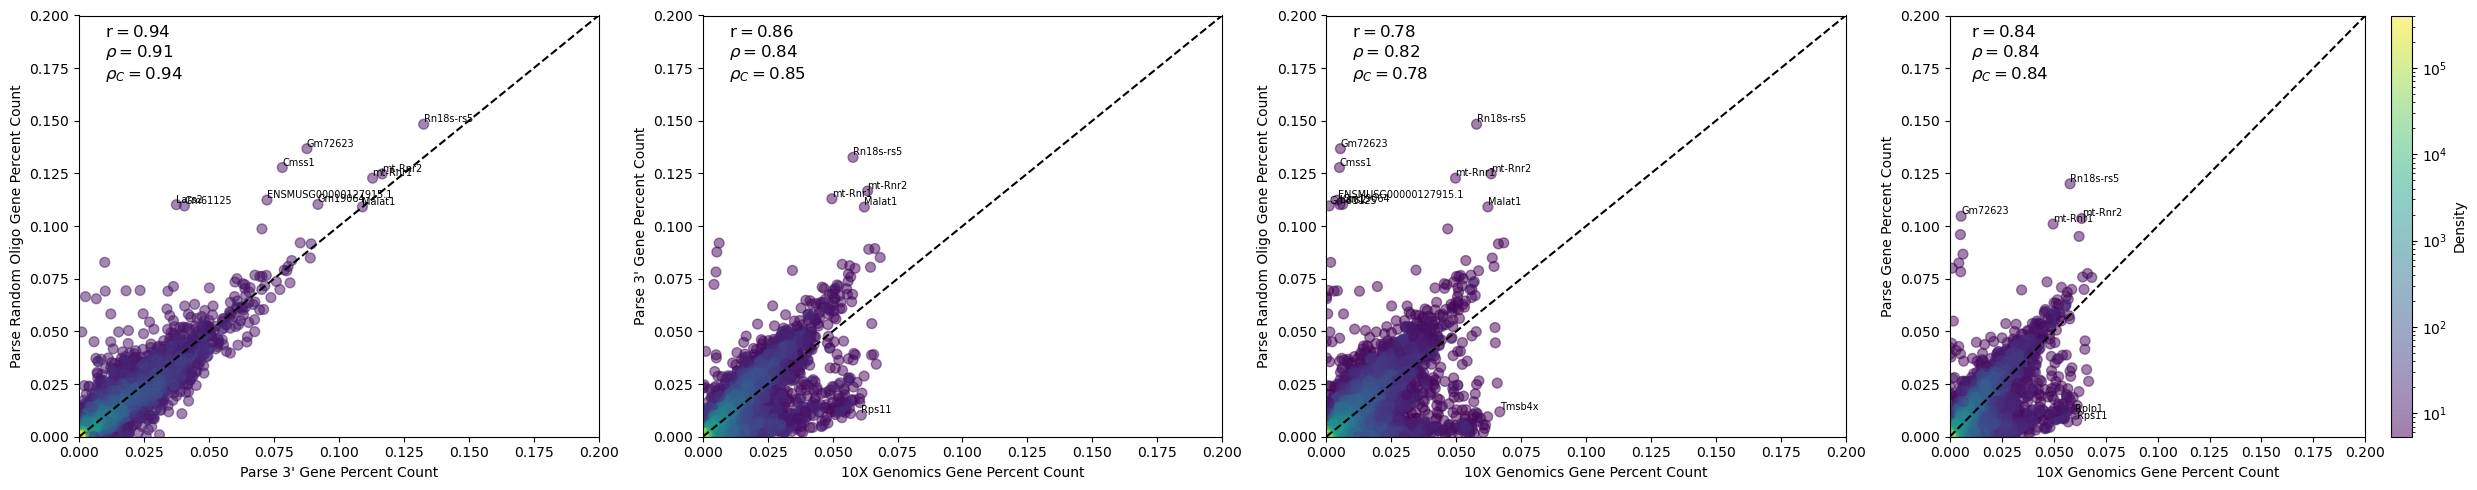

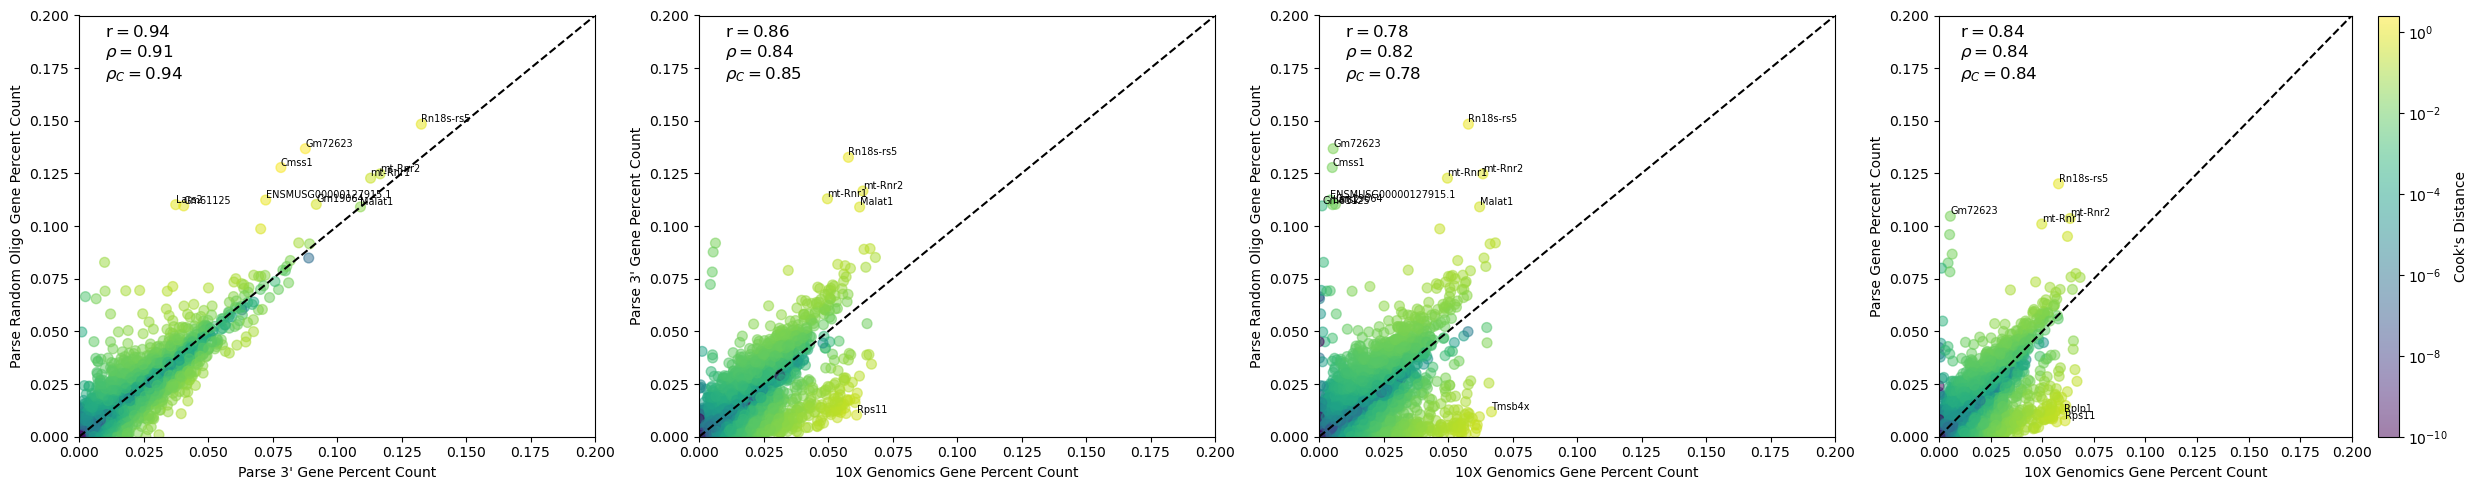

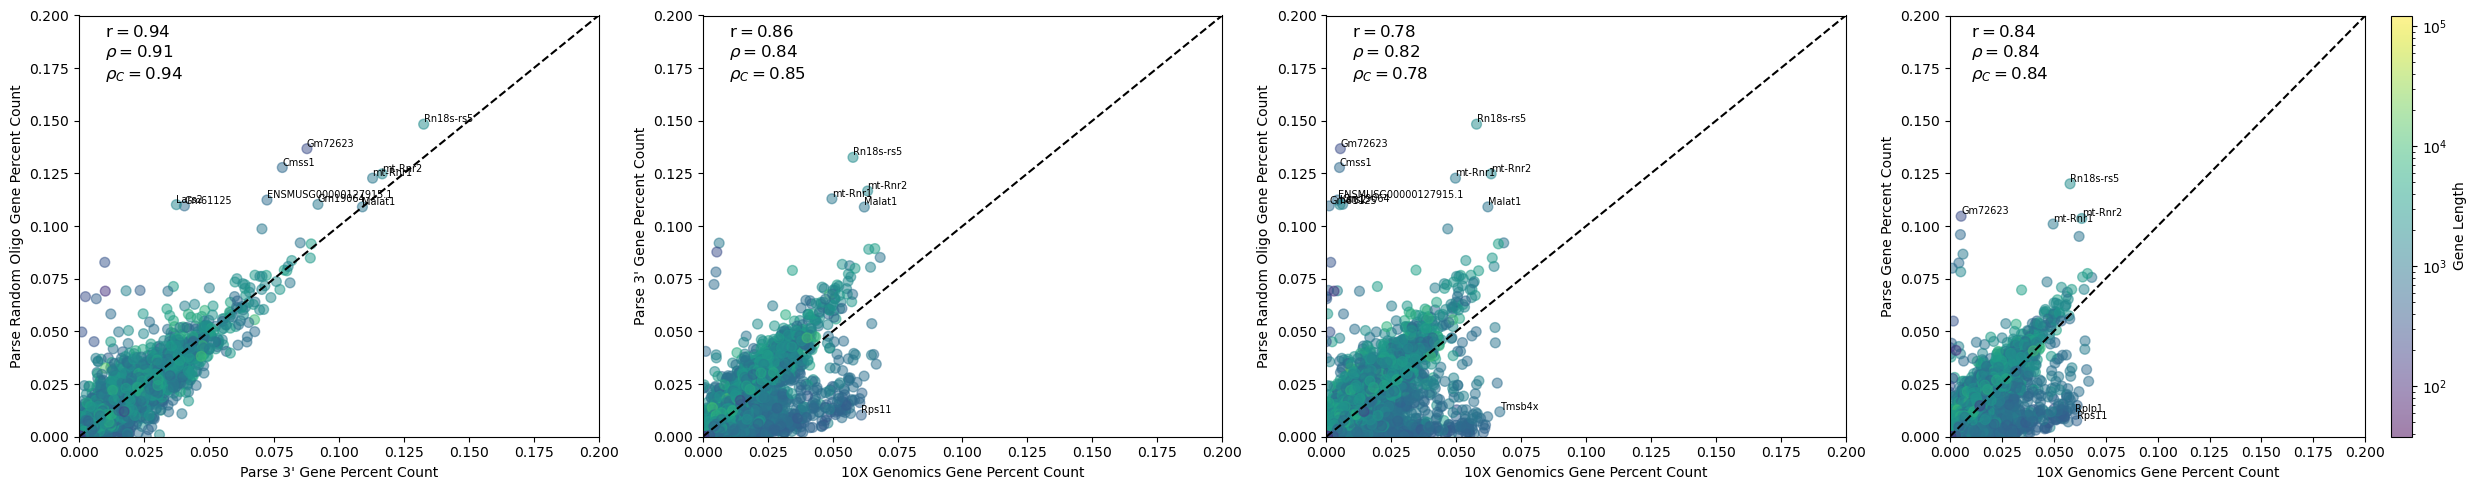

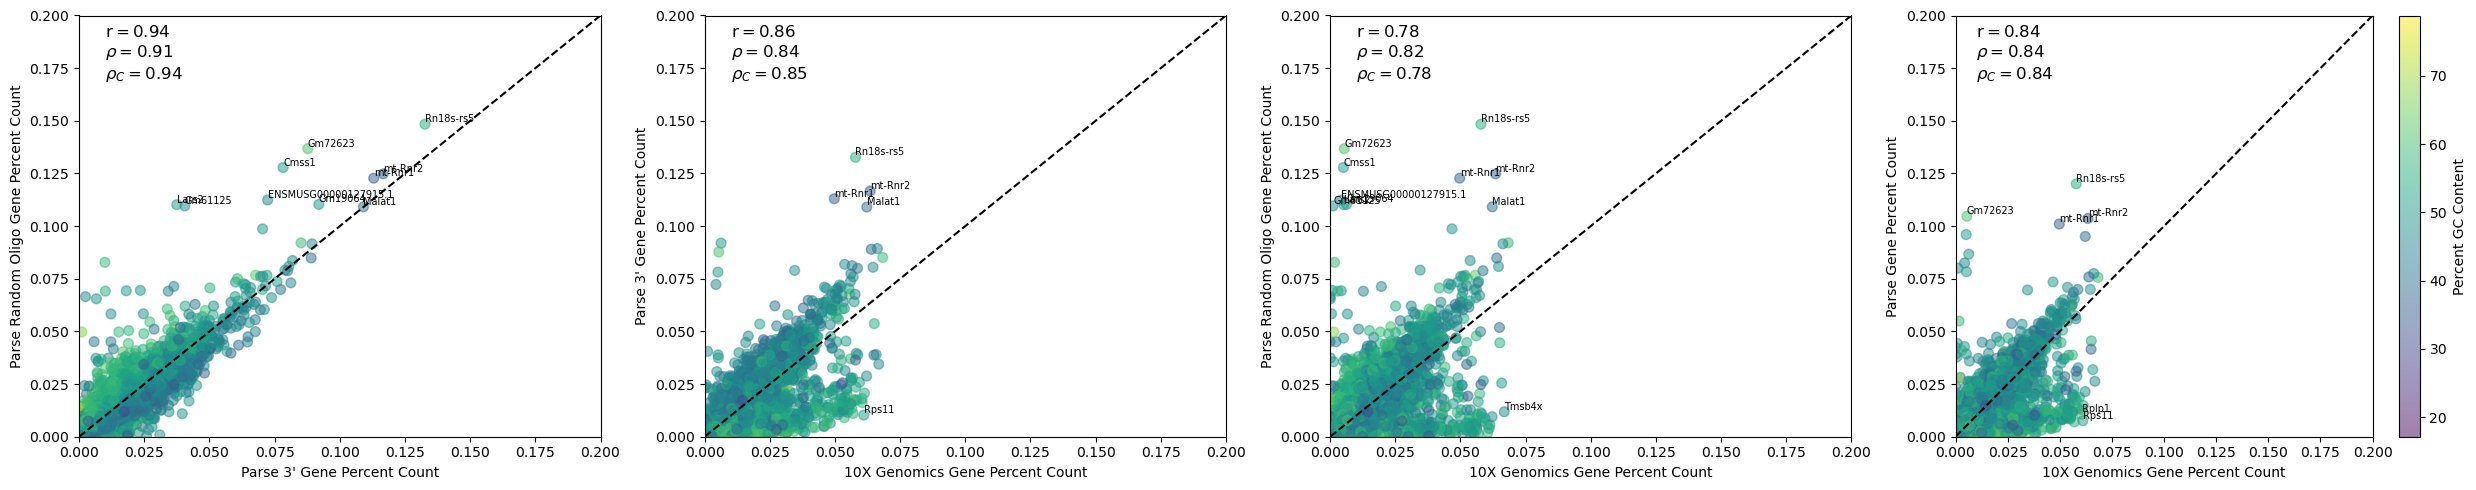

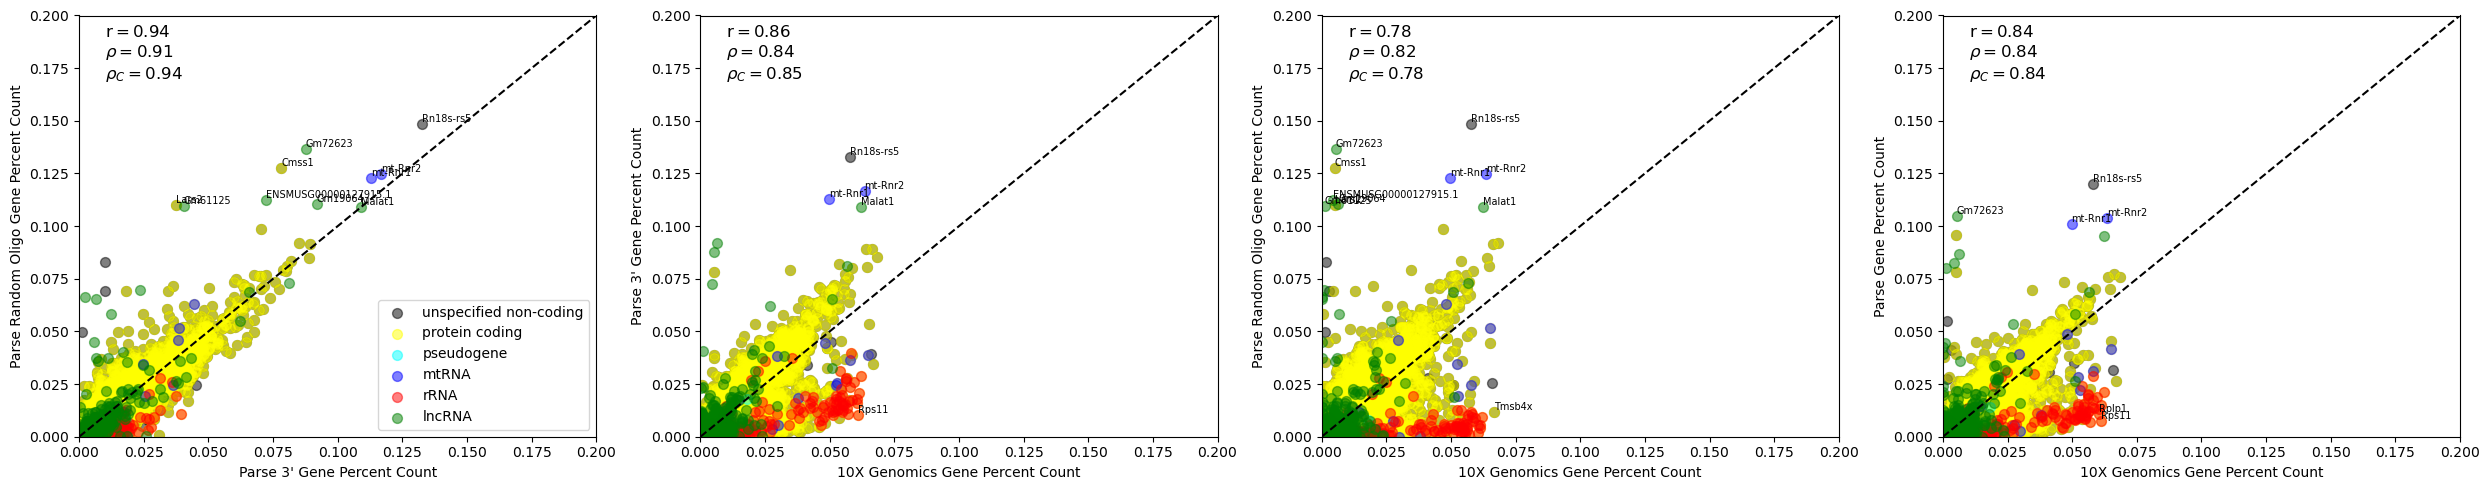

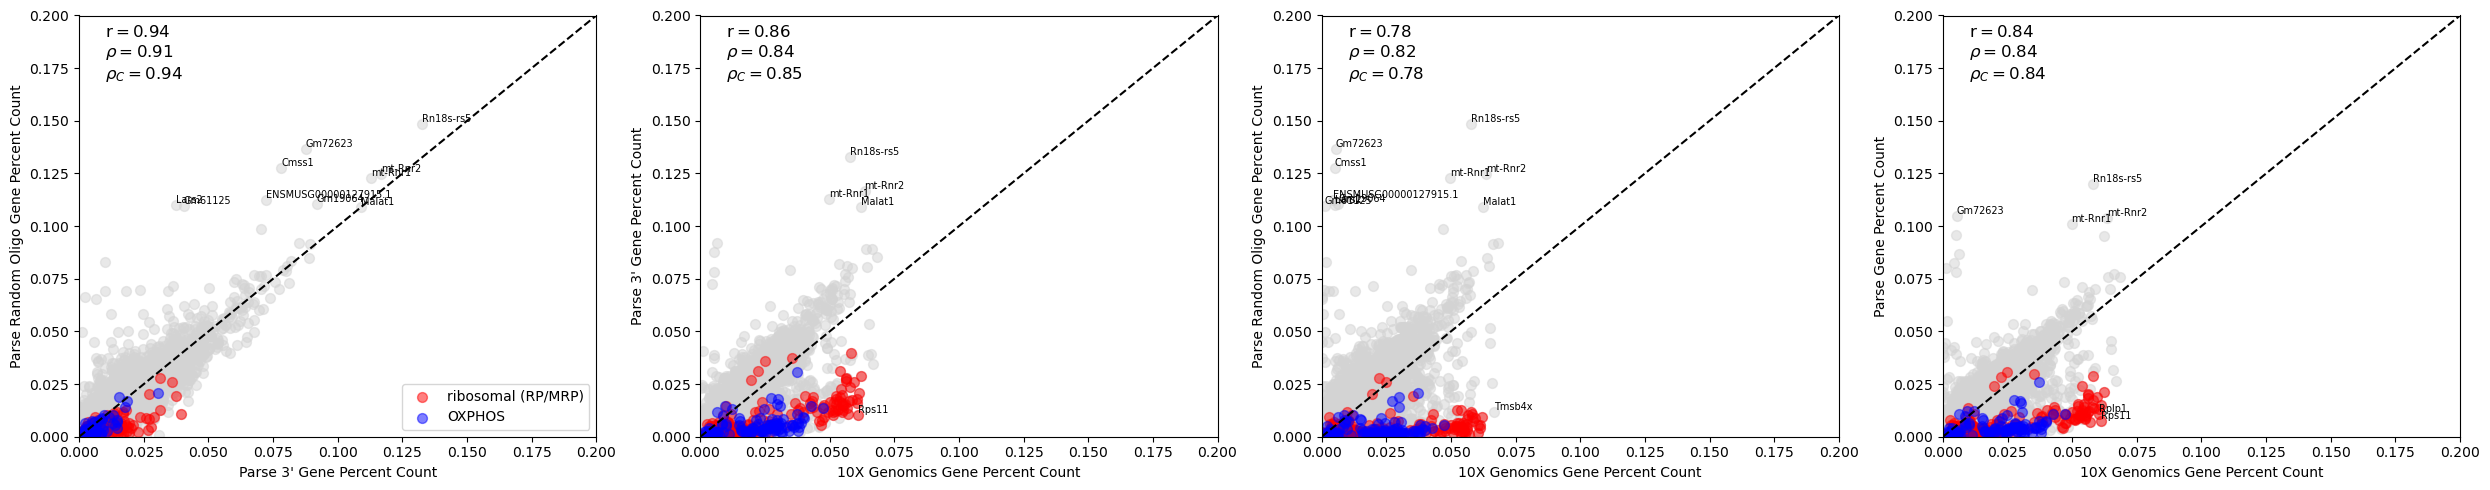

In [16]:
if LOGCPM_TRANSFORM:
    compare_names, compare_dfs = plotting.compare(datasets, 0.2)

In [23]:
if not LOGCPM_TRANSFORM:
    compare_names, compare_dfs = plotting.compare(datasets, 8)

In [24]:
if not LOGCPM_TRANSFORM:
    _, _ = plotting.compare(datasets, 1.5)

In [25]:
if not LOGCPM_TRANSFORM:
    _, _ = plotting.compare(datasets, 0.5)

In [26]:
if LOGCPM_TRANSFORM:
    lim = 0.2
else:
    lim = 1.2

In [27]:
data_10x = datasets[0]
data_polyT = datasets[1]
data_randO = datasets[2]
data_parse = datasets[3]

comparisons = [(data_polyT, data_randO),
                (data_10x, data_polyT),
                (data_10x, data_randO),
                (data_10x, data_parse)]

/home/mcaskey/10XvParse/XvP_utils/plotting/processing.py:257: UserWarning: compare_by_enrichment: 4 genes in "Mitochondrial Inner Membrane (GO:0005743)" but missing from data:
  ['ATP5MG', 'ATP5PO', 'IFI6', 'UQCRH']
  warnings.warn(
/home/mcaskey/10XvParse/XvP_utils/plotting/processing.py:257: UserWarning: compare_by_enrichment: 7 genes in "Mitochondrial Membrane (GO:0031966)" but missing from data:
  ['ATP5MG', 'ATP5PO', 'IFI27L1', 'IFI27L2', 'IFI6', 'TMEM14B', 'UQCRH']
  warnings.warn(


  Parse 3' vs Parse Random Oligo | Mitochondrial Inner Membrane (GO:0005743): 148/213 toward Parse 3', 65/213 toward Parse Random Oligo
  Parse 3' vs Parse Random Oligo | Mitochondrial Membrane (GO:0031966): 172/263 toward Parse 3', 91/263 toward Parse Random Oligo
  10X Genomics vs Parse 3' | Mitochondrial Inner Membrane (GO:0005743): 207/215 toward 10X Genomics, 8/215 toward Parse 3'
  10X Genomics vs Parse 3' | Mitochondrial Membrane (GO:0031966): 250/265 toward 10X Genomics, 15/265 toward Parse 3'
  10X Genomics vs Parse Random Oligo | Mitochondrial Inner Membrane (GO:0005743): 195/215 toward 10X Genomics, 20/215 toward Parse Random Oligo
  10X Genomics vs Parse Random Oligo | Mitochondrial Membrane (GO:0031966): 234/265 toward 10X Genomics, 31/265 toward Parse Random Oligo
  10X Genomics vs Parse | Mitochondrial Inner Membrane (GO:0005743): 199/215 toward 10X Genomics, 16/215 toward Parse
  10X Genomics vs Parse | Mitochondrial Membrane (GO:0031966): 239/265 toward 10X Genomics, 2

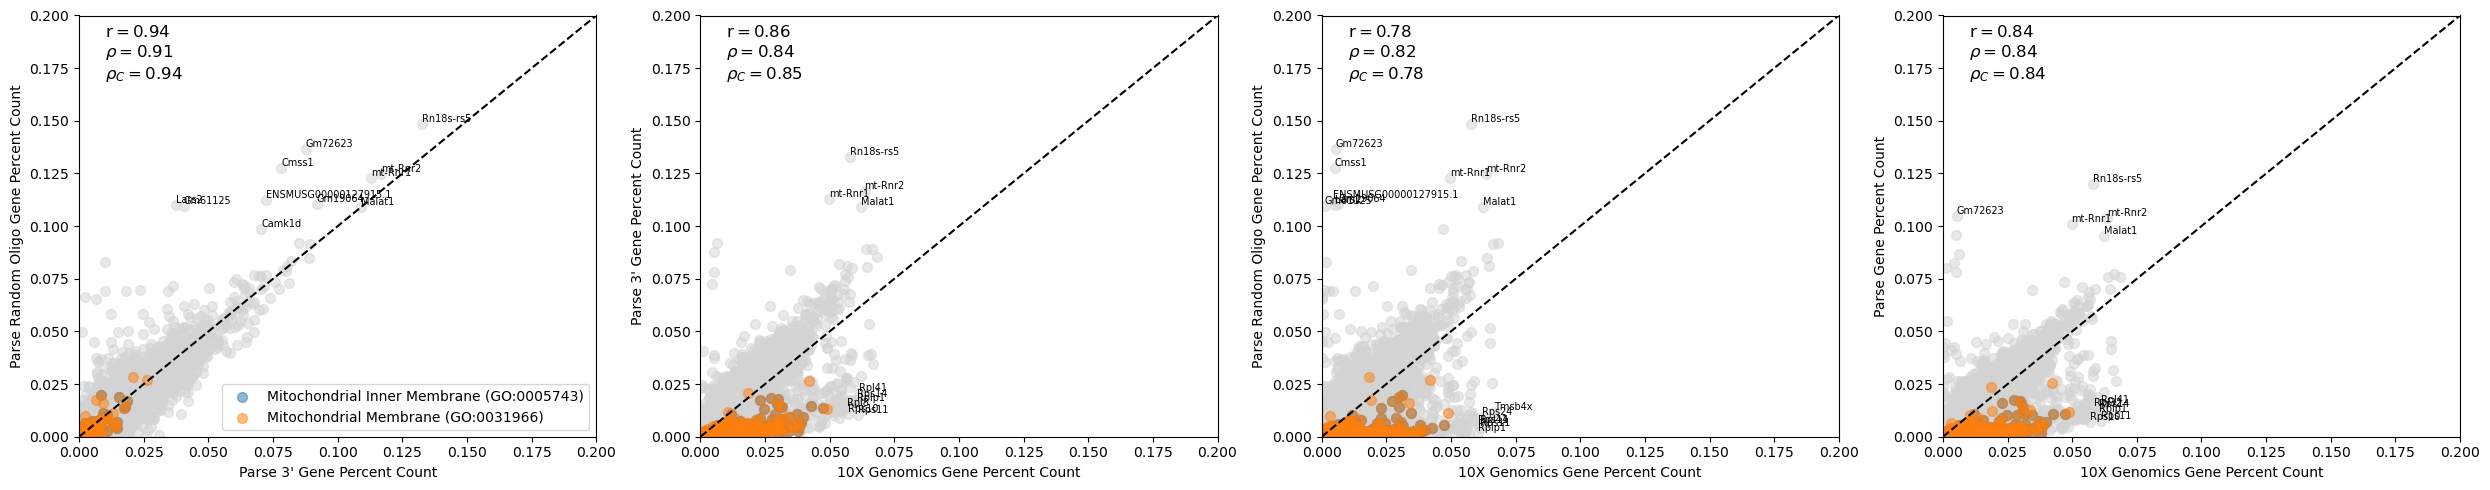

In [28]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=lim,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvPolyT/10x_outliers/enrichment_results.csv",
    gene_sets=["GO_Cellular_Component_2026"],
    terms=["Mitochondrial Inner Membrane (GO:0005743)", "Mitochondrial Membrane (GO:0031966)"])

/home/mcaskey/10XvParse/XvP_utils/plotting/processing.py:257: UserWarning: compare_by_enrichment: 19 genes in "Extracellular Exosome (GO:0070062)" but missing from data:
  ['AKR1C3', 'AKR1C4', 'AKR7A2', 'CETP', 'EIF2S3', 'GAL3ST4', 'GLOD4', 'H2AC4', 'H2AC6', 'H2BC9', 'HLA-C', 'HLA-DRB1', 'HLA-E', 'HSPA1B', 'HSPA6', 'LDHAL6A', 'RBP5', 'RPL26L1', 'S100P']
  warnings.warn(
/home/mcaskey/10XvParse/XvP_utils/plotting/processing.py:257: UserWarning: compare_by_enrichment: 19 genes in "Extracellular Vesicle (GO:1903561)" but missing from data:
  ['AKR1C3', 'AKR1C4', 'AKR7A2', 'CETP', 'EIF2S3', 'GAL3ST4', 'GLOD4', 'H2AC4', 'H2AC6', 'H2BC9', 'HLA-C', 'HLA-DRB1', 'HLA-E', 'HSPA1B', 'HSPA6', 'LDHAL6A', 'RBP5', 'RPL26L1', 'S100P']
  warnings.warn(


  Parse 3' vs Parse Random Oligo | Extracellular Exosome (GO:0070062): 263/538 toward Parse 3', 275/538 toward Parse Random Oligo
  Parse 3' vs Parse Random Oligo | Extracellular Vesicle (GO:1903561): 263/541 toward Parse 3', 278/541 toward Parse Random Oligo
  10X Genomics vs Parse 3' | Extracellular Exosome (GO:0070062): 449/538 toward 10X Genomics, 89/538 toward Parse 3'
  10X Genomics vs Parse 3' | Extracellular Vesicle (GO:1903561): 451/541 toward 10X Genomics, 90/541 toward Parse 3'
  10X Genomics vs Parse Random Oligo | Extracellular Exosome (GO:0070062): 406/537 toward 10X Genomics, 131/537 toward Parse Random Oligo
  10X Genomics vs Parse Random Oligo | Extracellular Vesicle (GO:1903561): 406/540 toward 10X Genomics, 134/540 toward Parse Random Oligo
  10X Genomics vs Parse | Extracellular Exosome (GO:0070062): 421/537 toward 10X Genomics, 116/537 toward Parse
  10X Genomics vs Parse | Extracellular Vesicle (GO:1903561): 423/540 toward 10X Genomics, 117/540 toward Parse


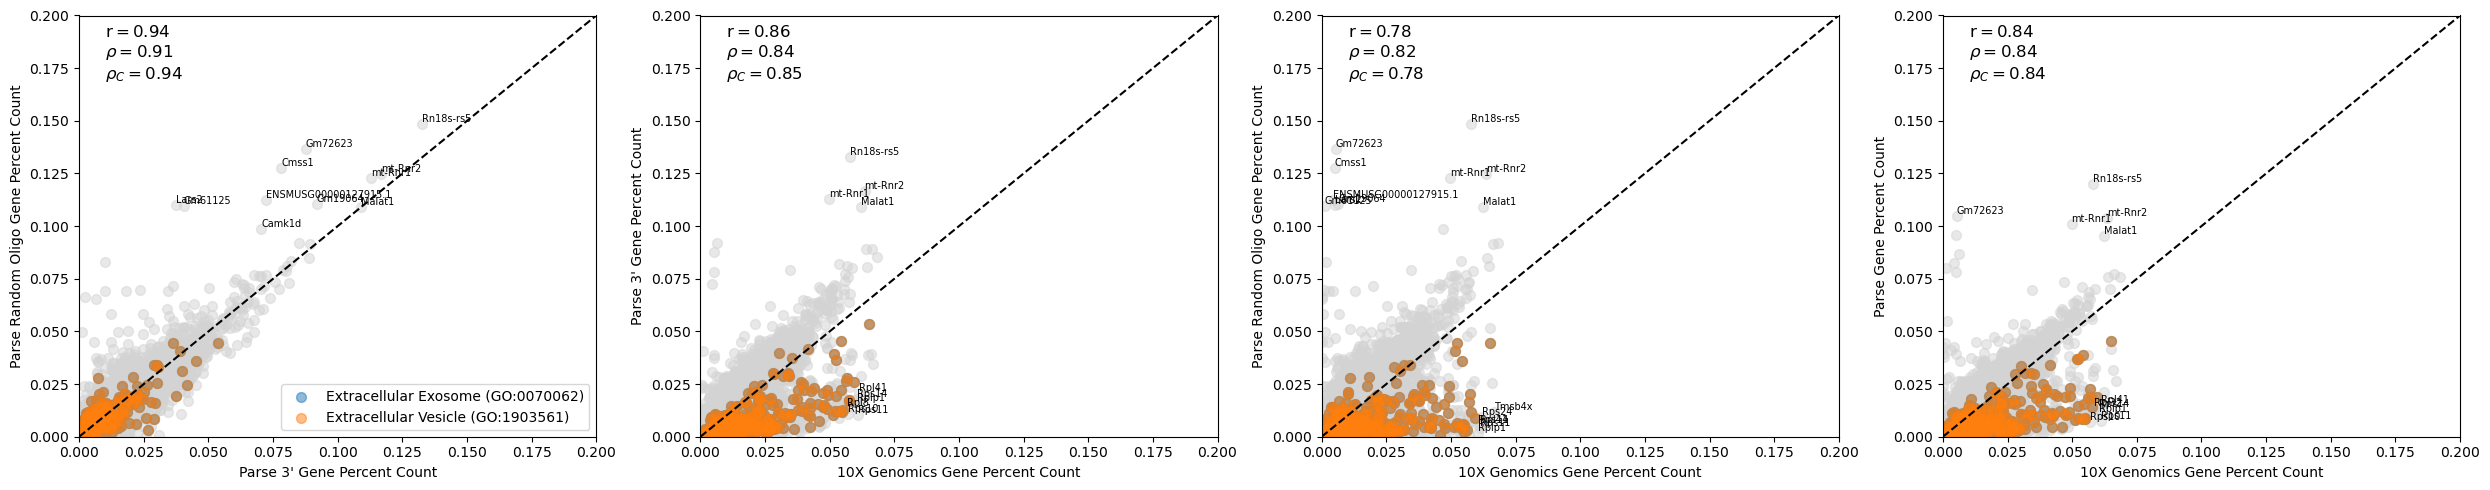

In [29]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=lim,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvPolyT/10x_outliers/enrichment_results.csv",
    gene_sets=["GO_Cellular_Component_2026"],
    terms=["Extracellular Exosome (GO:0070062)", "Extracellular Vesicle (GO:1903561)"])

  Parse 3' vs Parse Random Oligo | Ribosome Biogenesis (GO:0042254): 38/60 toward Parse 3', 22/60 toward Parse Random Oligo
  10X Genomics vs Parse 3' | Ribosome Biogenesis (GO:0042254): 57/63 toward 10X Genomics, 6/63 toward Parse 3'
  10X Genomics vs Parse Random Oligo | Ribosome Biogenesis (GO:0042254): 59/63 toward 10X Genomics, 4/63 toward Parse Random Oligo
  10X Genomics vs Parse | Ribosome Biogenesis (GO:0042254): 58/62 toward 10X Genomics, 4/62 toward Parse


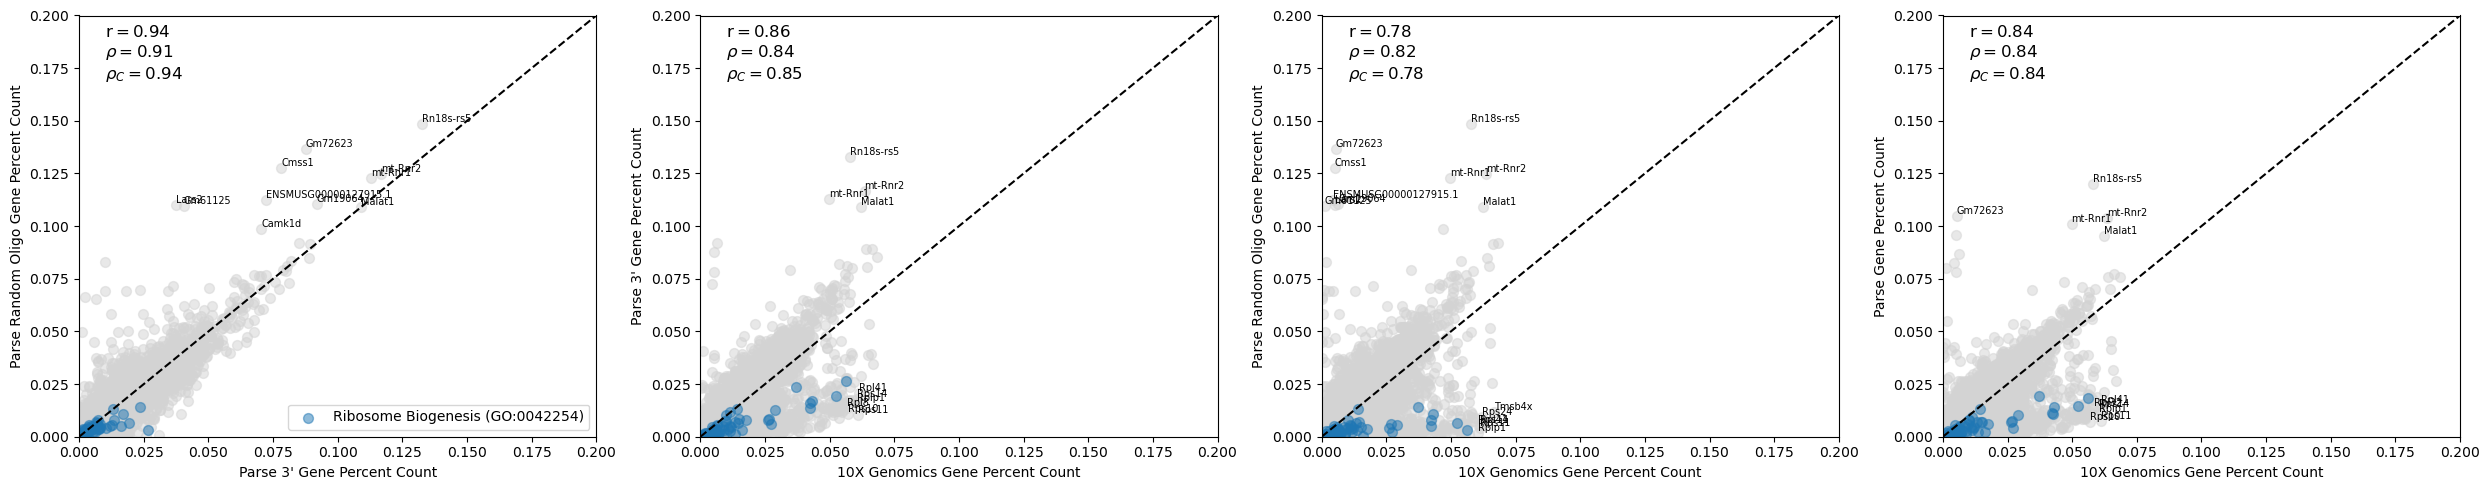

In [30]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=lim,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvPolyT/10x_outliers/enrichment_results.csv",
    gene_sets=["GO_Biological_Process_2026"],
    terms=["Ribosome Biogenesis (GO:0042254)"])

  Parse 3' vs Parse Random Oligo | Mitochondrial Translation (GO:0032543): 41/61 toward Parse 3', 20/61 toward Parse Random Oligo
  10X Genomics vs Parse 3' | Mitochondrial Translation (GO:0032543): 59/61 toward 10X Genomics, 2/61 toward Parse 3'
  10X Genomics vs Parse Random Oligo | Mitochondrial Translation (GO:0032543): 57/61 toward 10X Genomics, 4/61 toward Parse Random Oligo
  10X Genomics vs Parse | Mitochondrial Translation (GO:0032543): 58/61 toward 10X Genomics, 3/61 toward Parse


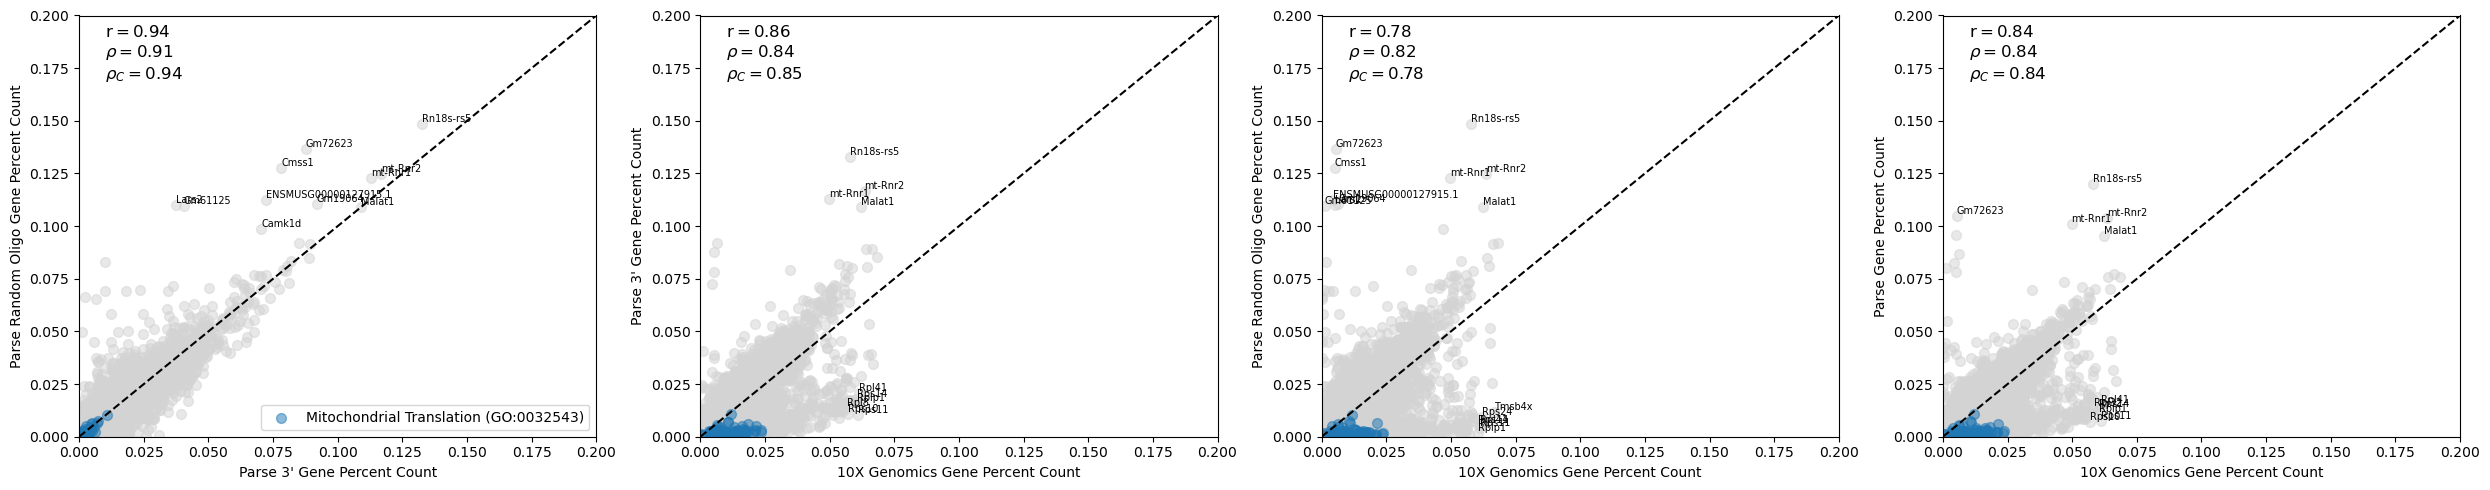

In [31]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=lim,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvPolyT/10x_outliers/enrichment_results.csv",
    gene_sets=["GO_Biological_Process_2026"],
    terms=["Mitochondrial Translation (GO:0032543)"])

/home/mcaskey/10XvParse/XvP_utils/plotting/processing.py:257: UserWarning: compare_by_enrichment: 2 genes in "Mitochondrial Respiratory Chain Complex Assembly (GO:0033108)" but missing from data:
  ['HIGD2A', 'PET117']
  warnings.warn(


  Parse 3' vs Parse Random Oligo | Mitochondrial Respiratory Chain Complex Assembly (GO:0033108): 38/50 toward Parse 3', 12/50 toward Parse Random Oligo
  10X Genomics vs Parse 3' | Mitochondrial Respiratory Chain Complex Assembly (GO:0033108): 47/50 toward 10X Genomics, 3/50 toward Parse 3'
  10X Genomics vs Parse Random Oligo | Mitochondrial Respiratory Chain Complex Assembly (GO:0033108): 47/50 toward 10X Genomics, 3/50 toward Parse Random Oligo
  10X Genomics vs Parse | Mitochondrial Respiratory Chain Complex Assembly (GO:0033108): 47/50 toward 10X Genomics, 3/50 toward Parse


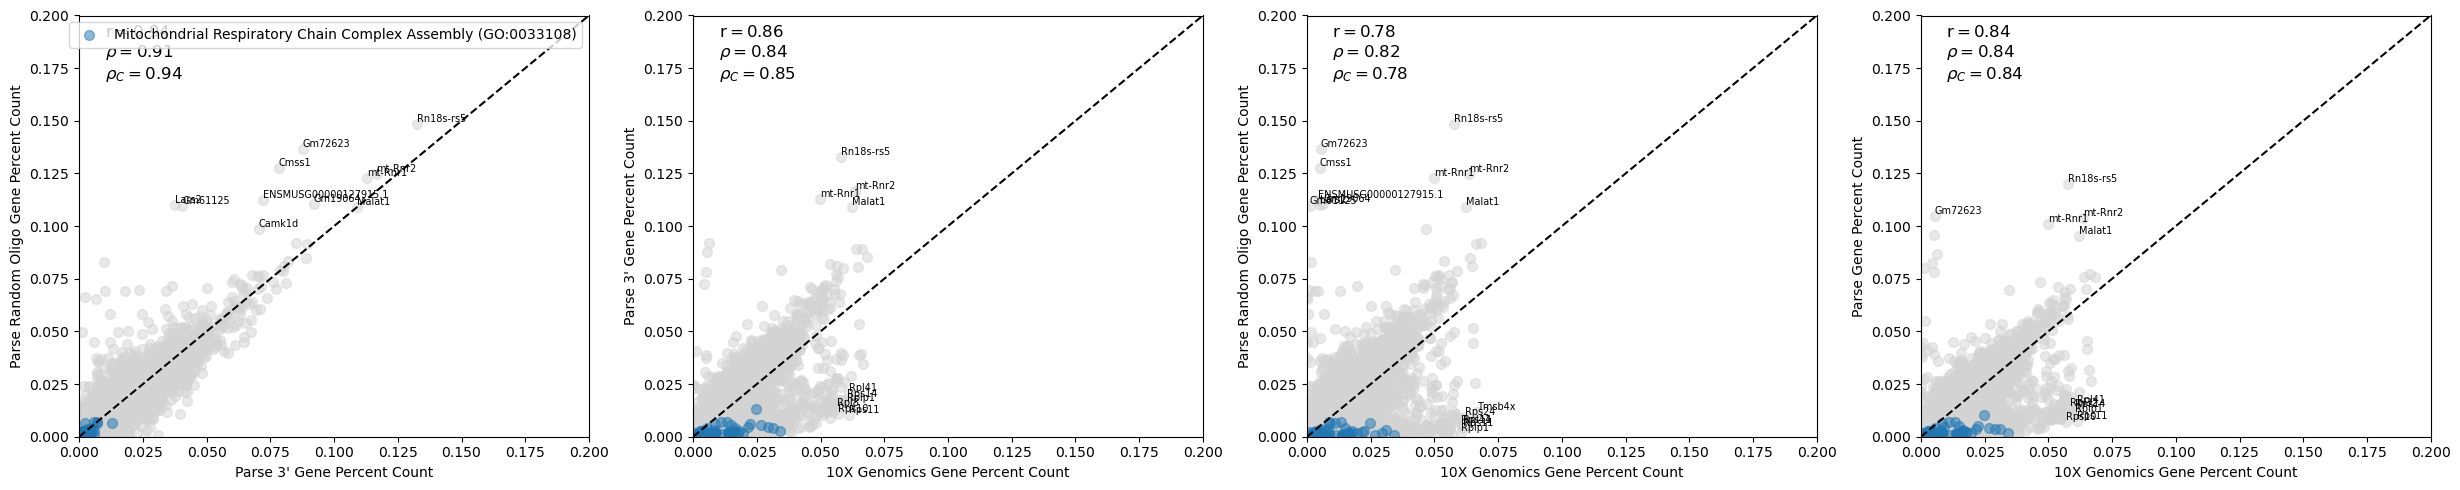

In [44]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=lim,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvPolyT/10x_outliers/enrichment_results.csv",
    gene_sets=["GO_Biological_Process_2026"],
    terms=["Mitochondrial Respiratory Chain Complex Assembly (GO:0033108)"])

/home/mcaskey/10XvParse/XvP_utils/plotting/processing.py:257: UserWarning: compare_by_enrichment: 7 genes in "Mitochondrial Membrane (GO:0031966)" but missing from data:
  ['ATP5MG', 'ATP5PO', 'IFI27L1', 'IFI27L2', 'IFI6', 'TMEM14B', 'UQCRH']
  warnings.warn(
/home/mcaskey/10XvParse/XvP_utils/plotting/processing.py:257: UserWarning: compare_by_enrichment: 19 genes in "Extracellular Vesicle (GO:1903561)" but missing from data:
  ['AKR1C3', 'AKR1C4', 'AKR7A2', 'CETP', 'EIF2S3', 'GAL3ST4', 'GLOD4', 'H2AC4', 'H2AC6', 'H2BC9', 'HLA-C', 'HLA-DRB1', 'HLA-E', 'HSPA1B', 'HSPA6', 'LDHAL6A', 'RBP5', 'RPL26L1', 'S100P']
  warnings.warn(
/home/mcaskey/10XvParse/XvP_utils/plotting/processing.py:257: UserWarning: compare_by_enrichment: 1 genes in "Large Ribosomal Subunit (GO:0015934)" but missing from data:
  ['RPL26L1']
  warnings.warn(


  Parse 3' vs Parse Random Oligo | Mitochondrial Membrane (GO:0031966): 172/263 toward Parse 3', 91/263 toward Parse Random Oligo
  Parse 3' vs Parse Random Oligo | Extracellular Vesicle (GO:1903561): 263/541 toward Parse 3', 278/541 toward Parse Random Oligo
  Parse 3' vs Parse Random Oligo | Large Ribosomal Subunit (GO:0015934): 45/52 toward Parse 3', 7/52 toward Parse Random Oligo
  10X Genomics vs Parse 3' | Mitochondrial Membrane (GO:0031966): 250/265 toward 10X Genomics, 15/265 toward Parse 3'
  10X Genomics vs Parse 3' | Extracellular Vesicle (GO:1903561): 451/541 toward 10X Genomics, 90/541 toward Parse 3'
  10X Genomics vs Parse 3' | Large Ribosomal Subunit (GO:0015934): 51/52 toward 10X Genomics, 1/52 toward Parse 3'
  10X Genomics vs Parse Random Oligo | Mitochondrial Membrane (GO:0031966): 234/265 toward 10X Genomics, 31/265 toward Parse Random Oligo
  10X Genomics vs Parse Random Oligo | Extracellular Vesicle (GO:1903561): 406/540 toward 10X Genomics, 134/540 toward Parse 

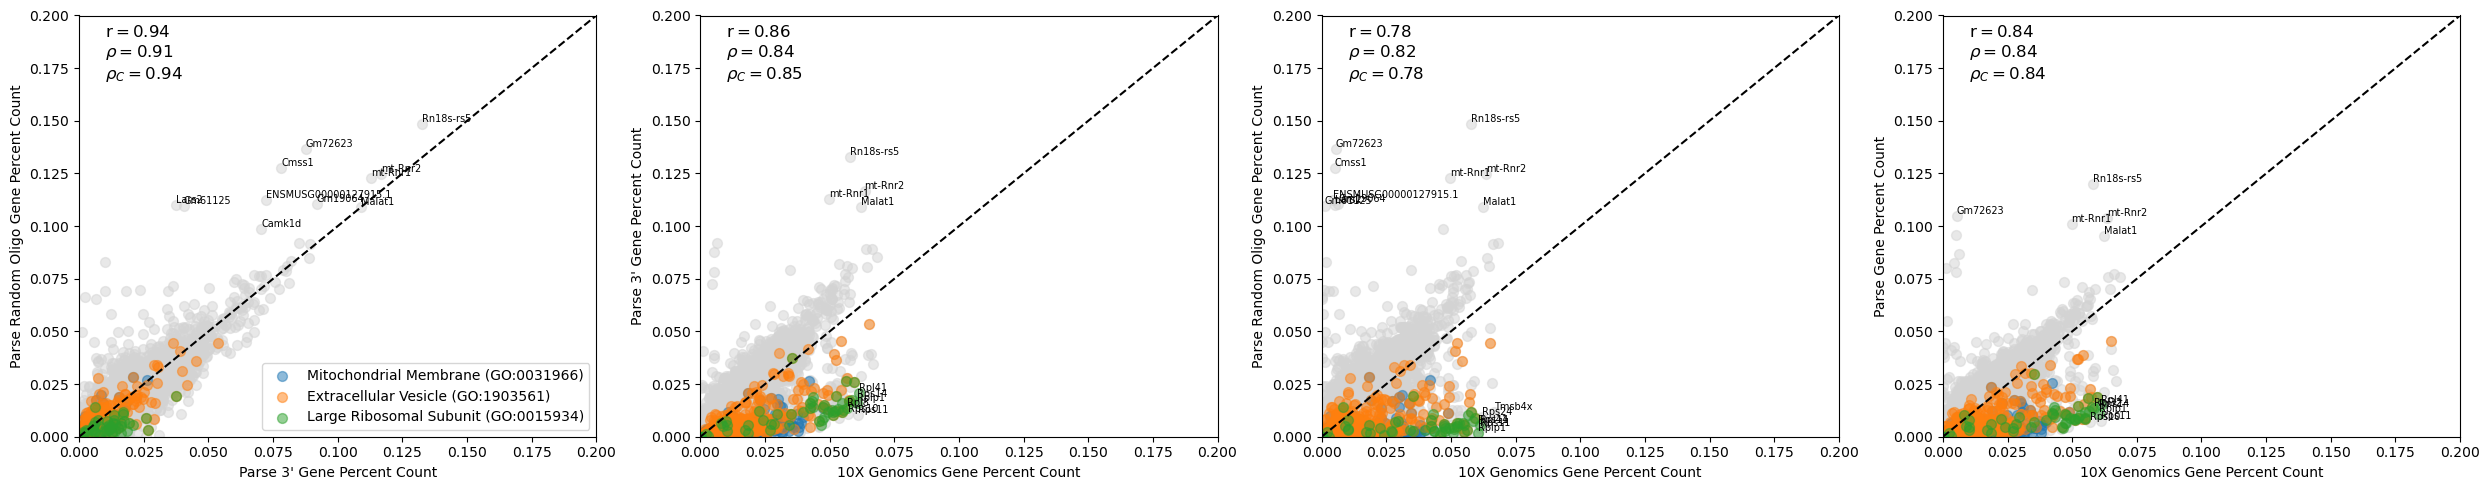

In [33]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=lim,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvPolyT/10x_outliers/enrichment_results.csv",
    gene_sets=["GO_Cellular_Component_2026"],
    terms=["Extracellular Vesicle (GO:1903561)", "Mitochondrial Membrane (GO:0031966)", "Large Ribosomal Subunit (GO:0015934)"])

  Parse 3' vs Parse Random Oligo | Extracellular Vesicle: 961/2085 toward Parse 3', 1124/2085 toward Parse Random Oligo
  Parse 3' vs Parse Random Oligo | Mitochondrial Membrane: 365/613 toward Parse 3', 248/613 toward Parse Random Oligo
  Parse 3' vs Parse Random Oligo | Large Ribosomal Subunit: 50/58 toward Parse 3', 8/58 toward Parse Random Oligo
  10X Genomics vs Parse 3' | Extracellular Vesicle: 1120/2074 toward 10X Genomics, 954/2074 toward Parse 3'
  10X Genomics vs Parse 3' | Mitochondrial Membrane: 426/613 toward 10X Genomics, 187/613 toward Parse 3'
  10X Genomics vs Parse 3' | Large Ribosomal Subunit: 55/58 toward 10X Genomics, 3/58 toward Parse 3'
  10X Genomics vs Parse Random Oligo | Extracellular Vesicle: 1044/2071 toward 10X Genomics, 1027/2071 toward Parse Random Oligo
  10X Genomics vs Parse Random Oligo | Mitochondrial Membrane: 405/613 toward 10X Genomics, 208/613 toward Parse Random Oligo
  10X Genomics vs Parse Random Oligo | Large Ribosomal Subunit: 55/57 toward 

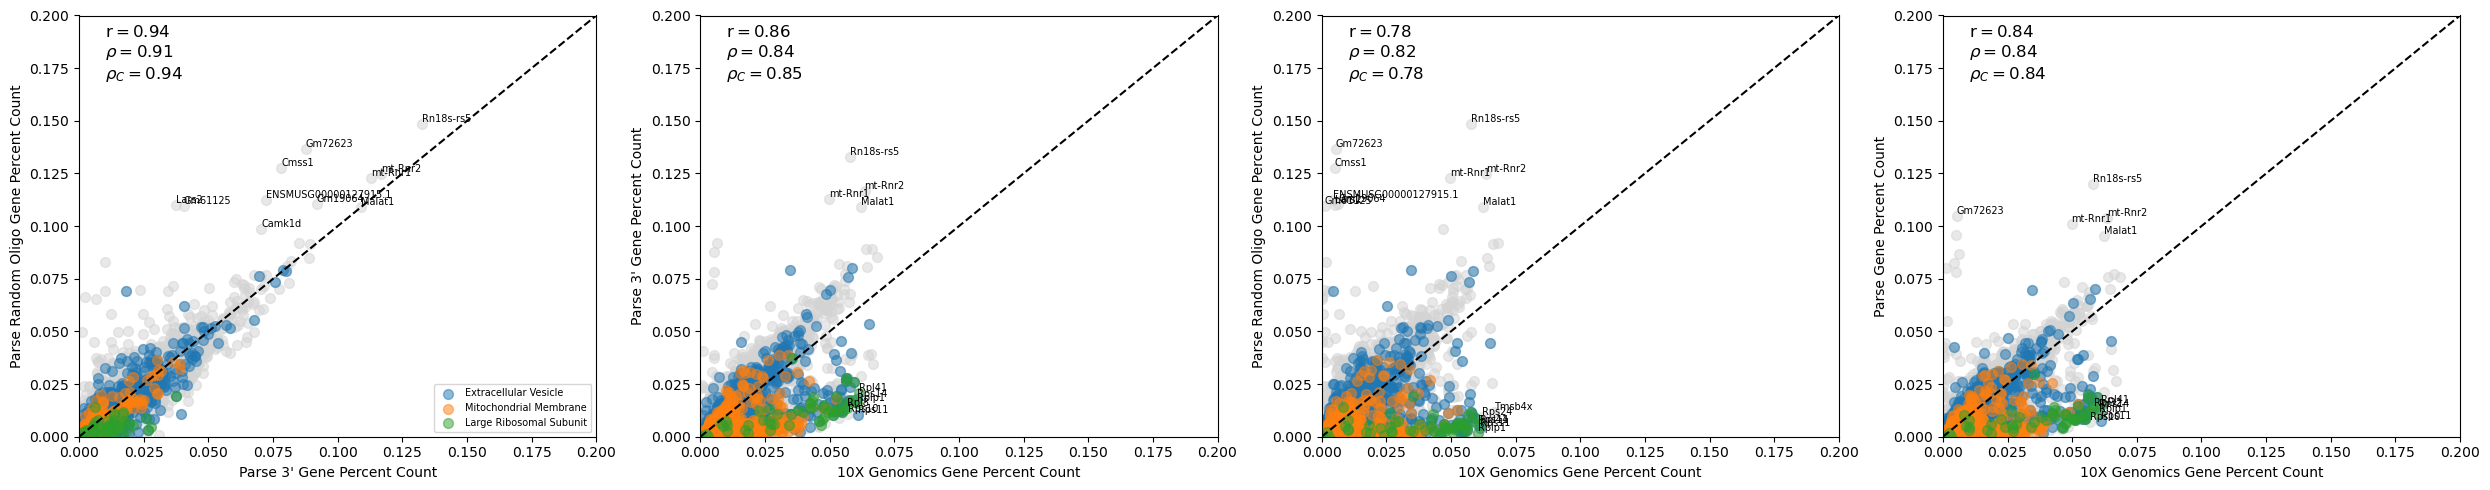

In [45]:
plotting.compare_by_go(
    compare_dfs, comparisons, lim=lim,
    terms=["Extracellular Vesicle (GO:1903561)", "Mitochondrial Membrane (GO:0031966)", "Large Ribosomal Subunit (GO:0015934)"],
    label_genes=False)

  Parse 3' vs Parse Random Oligo | GTPase Regulator Activity: 176/440 toward Parse 3', 264/440 toward Parse Random Oligo
  Parse 3' vs Parse Random Oligo | Protein Serine/Threonine Kinase Activity: 147/375 toward Parse 3', 228/375 toward Parse Random Oligo
  10X Genomics vs Parse 3' | GTPase Regulator Activity: 149/440 toward 10X Genomics, 291/440 toward Parse 3'
  10X Genomics vs Parse 3' | Protein Serine/Threonine Kinase Activity: 124/373 toward 10X Genomics, 249/373 toward Parse 3'
  10X Genomics vs Parse Random Oligo | GTPase Regulator Activity: 114/440 toward 10X Genomics, 326/440 toward Parse Random Oligo
  10X Genomics vs Parse Random Oligo | Protein Serine/Threonine Kinase Activity: 107/375 toward 10X Genomics, 268/375 toward Parse Random Oligo
  10X Genomics vs Parse | GTPase Regulator Activity: 112/440 toward 10X Genomics, 328/440 toward Parse
  10X Genomics vs Parse | Protein Serine/Threonine Kinase Activity: 92/375 toward 10X Genomics, 283/375 toward Parse


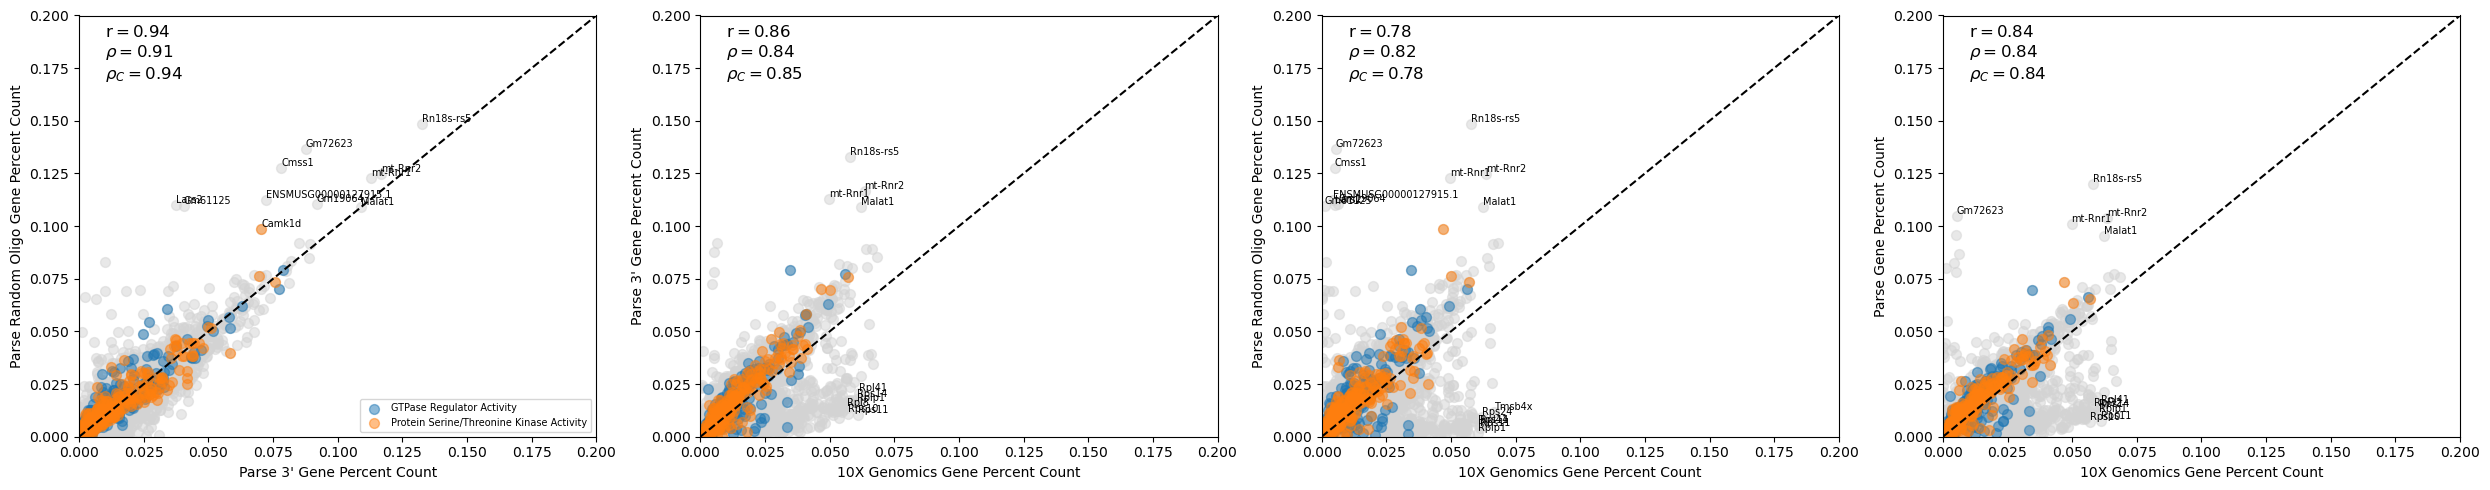

In [46]:
plotting.compare_by_go(
    compare_dfs, comparisons, lim=lim,
    terms=["GTPase Regulator Activity (GO:0030695)", "Protein Serine/Threonine Kinase Activity (GO:0004674)"],
    go_library="GO_Molecular_Function_2026",
    label_genes=False)

/home/mcaskey/10XvParse/XvP_utils/plotting/processing.py:257: UserWarning: compare_by_enrichment: 5 genes in "GTPase Regulator Activity (GO:0030695)" but missing from data:
  ['AGAP9', 'ARHGAP26', 'MCF2L2', 'TBC1D3', 'TBC1D3L']
  warnings.warn(
/home/mcaskey/10XvParse/XvP_utils/plotting/processing.py:257: UserWarning: compare_by_enrichment: 1 genes in "Protein Serine/Threonine Kinase Activity (GO:0004674)" but missing from data:
  ['CDK11A']
  warnings.warn(


  Parse 3' vs Parse Random Oligo | GTPase Regulator Activity (GO:0030695): 47/93 toward Parse 3', 46/93 toward Parse Random Oligo
  Parse 3' vs Parse Random Oligo | Protein Serine/Threonine Kinase Activity (GO:0004674): 38/66 toward Parse 3', 28/66 toward Parse Random Oligo
  10X Genomics vs Parse 3' | GTPase Regulator Activity (GO:0030695): 14/93 toward 10X Genomics, 79/93 toward Parse 3'
  10X Genomics vs Parse 3' | Protein Serine/Threonine Kinase Activity (GO:0004674): 6/66 toward 10X Genomics, 60/66 toward Parse 3'
  10X Genomics vs Parse Random Oligo | GTPase Regulator Activity (GO:0030695): 14/93 toward 10X Genomics, 79/93 toward Parse Random Oligo
  10X Genomics vs Parse Random Oligo | Protein Serine/Threonine Kinase Activity (GO:0004674): 11/66 toward 10X Genomics, 55/66 toward Parse Random Oligo
  10X Genomics vs Parse | GTPase Regulator Activity (GO:0030695): 13/93 toward 10X Genomics, 80/93 toward Parse
  10X Genomics vs Parse | Protein Serine/Threonine Kinase Activity (GO:0

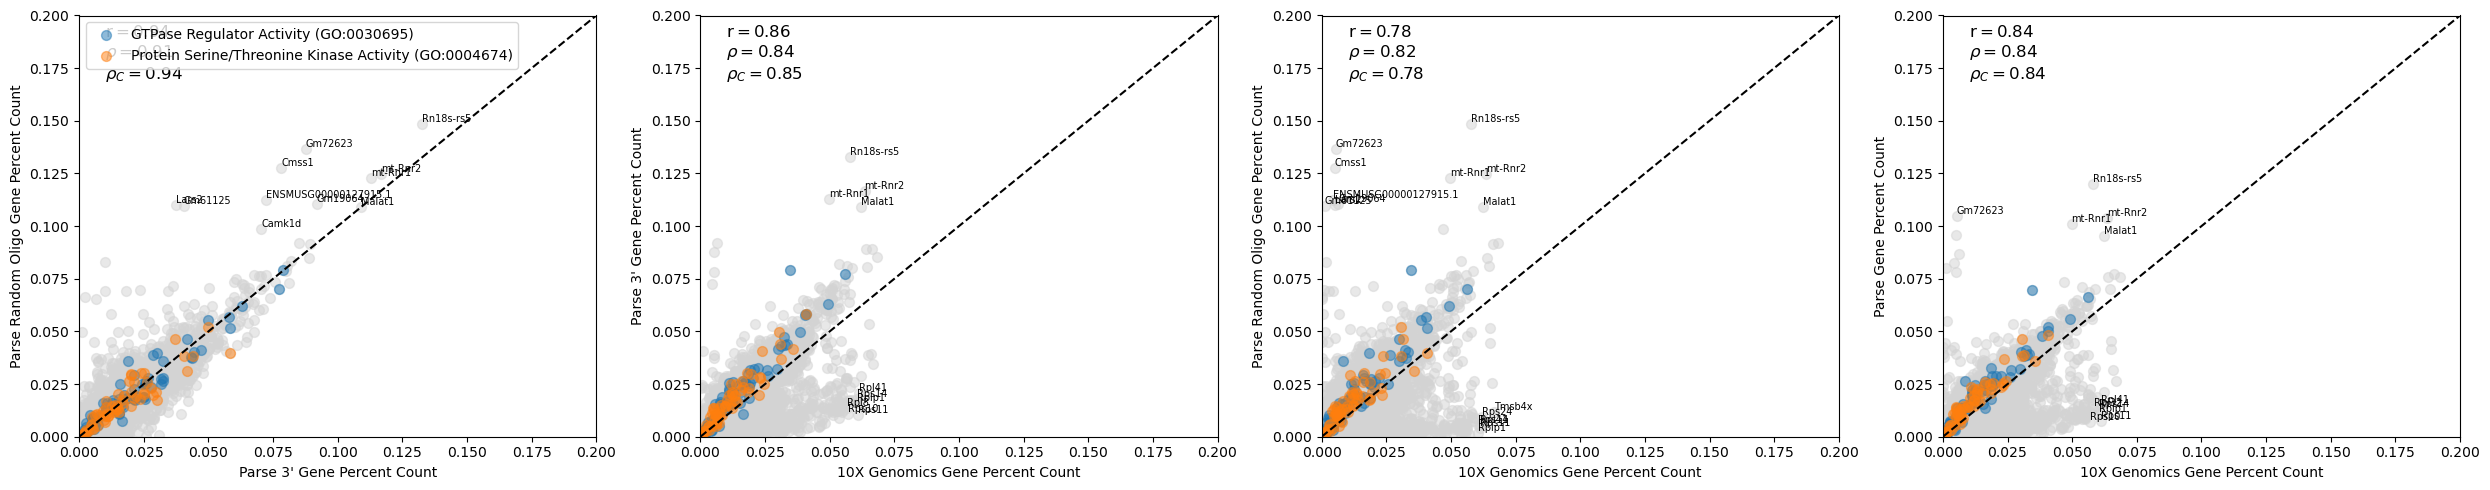

In [ ]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=lim,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvPolyT/polyT_outliers/enrichment_results.csv",
    gene_sets=["GO_Molecular_Function_2026", "MSigDB_Hallmark_2020"],
    terms=["GTPase Regulator Activity (GO:0030695)","Mitotic Spindle", "Protein Serine/Threonine Kinase Activity (GO:0004674)"])

/home/mcaskey/10XvParse/XvP_utils/plotting/processing.py:257: UserWarning: compare_by_enrichment: 52 genes in "Nucleus (GO:0005634)" but missing from data:
  ['AK6', 'AKR1C3', 'APOBEC3B', 'APOBEC3C', 'APOBEC3F', 'APOBEC3G', 'ATP5PO', 'BEX1', 'DDIT3', 'EIF2S3', 'EXOSC6', 'F8A1', 'GCAT', 'GLI4', 'H2AC4', 'H2AC6', 'H2BC9', 'HES4', 'HMGN4', 'HSPA1B', 'HSPA6', 'LGALS9', 'MAGEF1', 'MT1E', 'MT1F', 'MT1X', 'MT2A', 'RBP5', 'S100P', 'SLC2A4RG', 'THAP5', 'TSC22D4', 'ZBED2', 'ZNF135', 'ZNF302', 'ZNF404', 'ZNF416', 'ZNF433', 'ZNF554', 'ZNF581', 'ZNF599', 'ZNF626', 'ZNF677', 'ZNF684', 'ZNF709', 'ZNF71', 'ZNF765', 'ZNF79', 'ZNF823', 'ZNF837', 'ZNF850', 'ZNF880']
  warnings.warn(


  Parse 3' vs Parse Random Oligo | Nucleus (GO:0005634): 461/964 toward Parse 3', 503/964 toward Parse Random Oligo
  10X Genomics vs Parse 3' | Nucleus (GO:0005634): 804/965 toward 10X Genomics, 161/965 toward Parse 3'
  10X Genomics vs Parse Random Oligo | Nucleus (GO:0005634): 699/966 toward 10X Genomics, 267/966 toward Parse Random Oligo
  10X Genomics vs Parse | Nucleus (GO:0005634): 731/965 toward 10X Genomics, 234/965 toward Parse


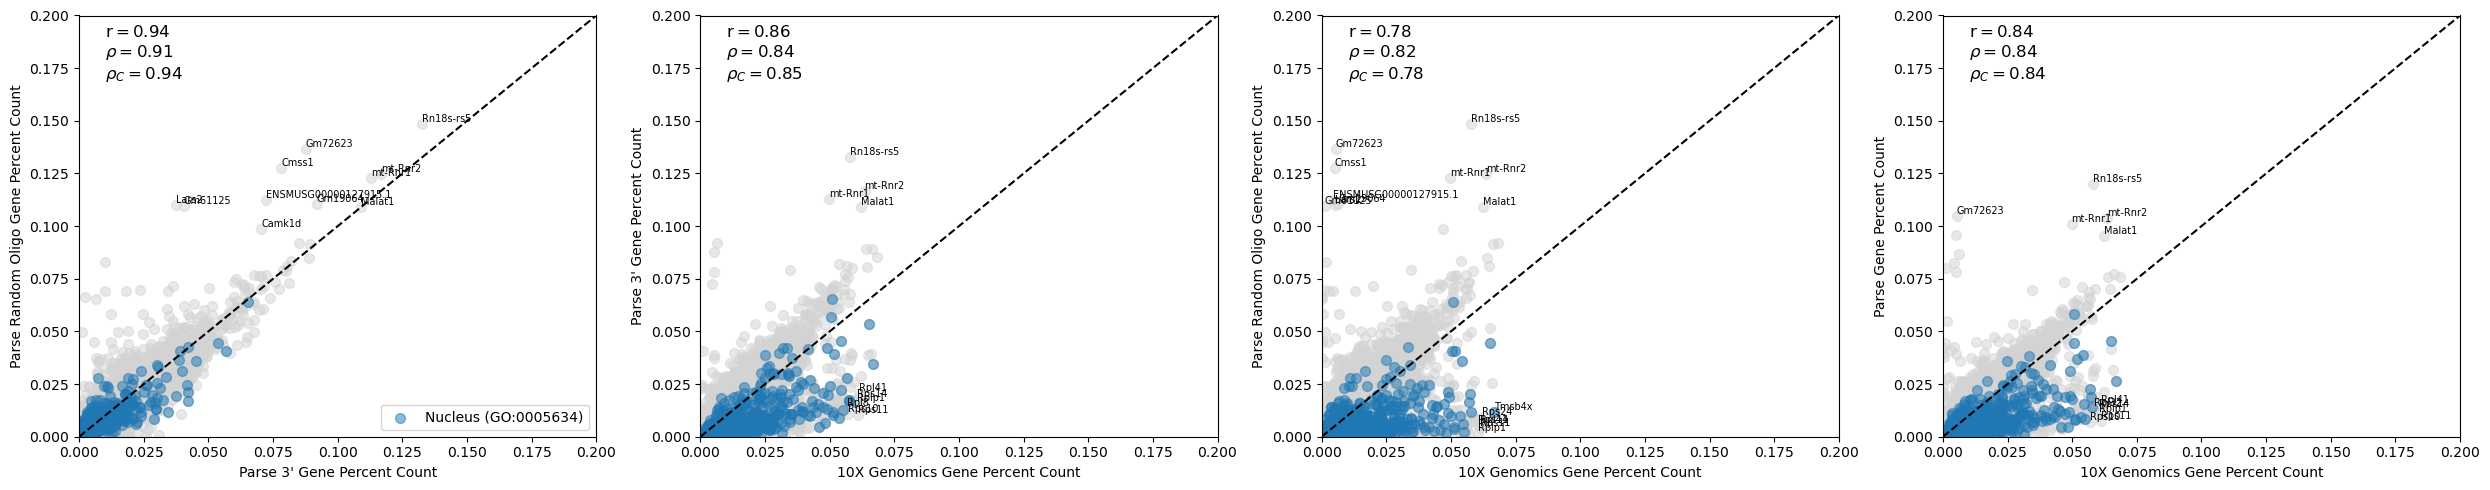

In [ ]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=lim,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvPolyT/10x_outliers/enrichment_results.csv",
    gene_sets=["GO_Cellular_Component_2026"],
    terms=["Nucleus (GO:0005634)"])

/home/mcaskey/10XvParse/XvP_utils/plotting/processing.py:257: UserWarning: compare_by_enrichment: 1 genes in "Mouse Housekeeping Genes" but missing from data:
  ['']
  warnings.warn(


  Parse 3' vs Parse Random Oligo | Mouse Housekeeping Genes: 633/1150 toward Parse 3', 517/1150 toward Parse Random Oligo
  10X Genomics vs Parse 3' | Mouse Housekeeping Genes: 687/1153 toward 10X Genomics, 466/1153 toward Parse 3'
  10X Genomics vs Parse Random Oligo | Mouse Housekeeping Genes: 674/1154 toward 10X Genomics, 480/1154 toward Parse Random Oligo
  10X Genomics vs Parse | Mouse Housekeeping Genes: 633/1154 toward 10X Genomics, 521/1154 toward Parse


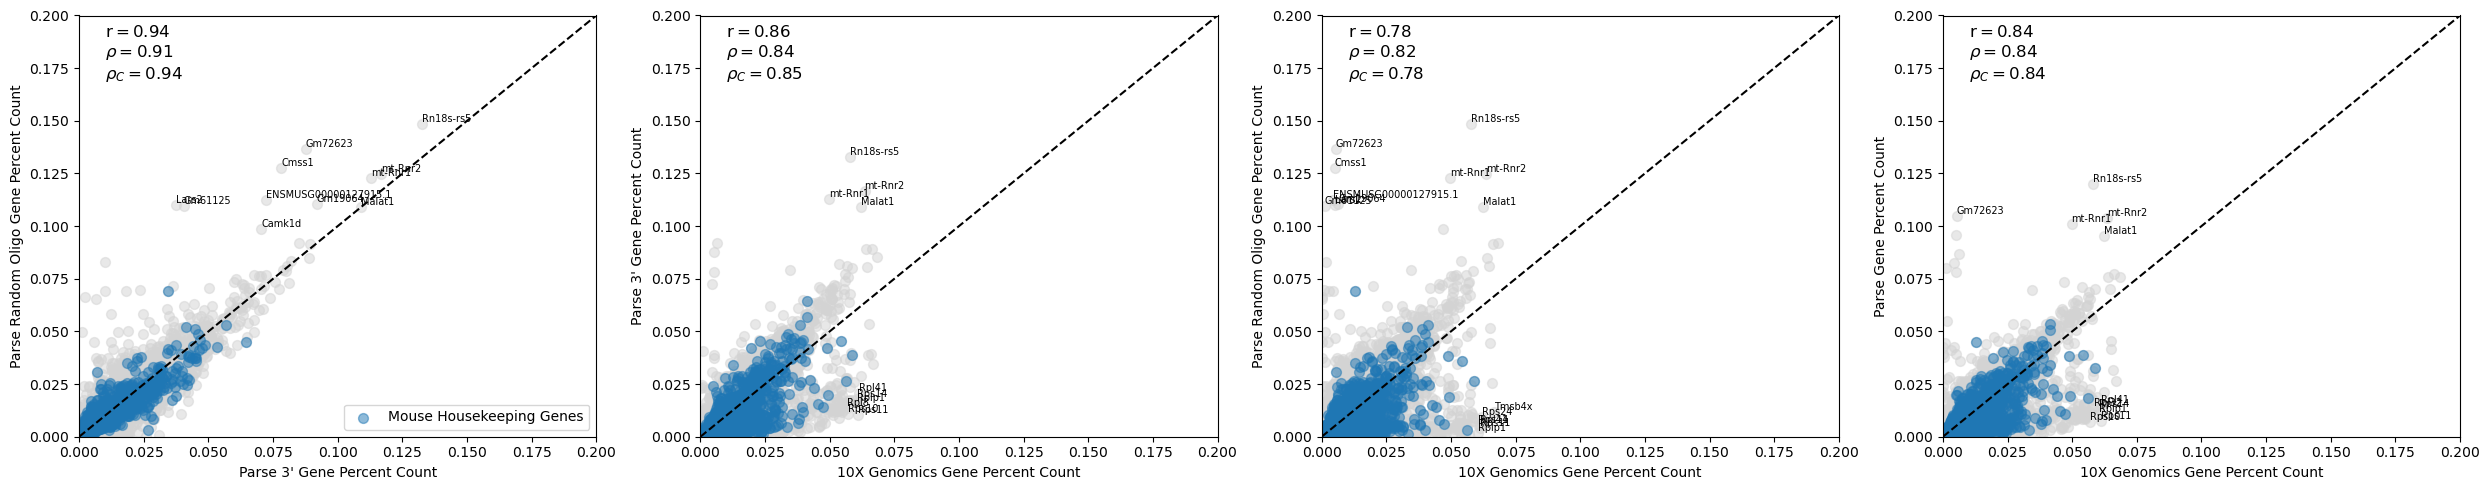

In [ ]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=lim,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/important_gene_sets.csv",
    gene_sets=["Housekeeping"],
    terms=["Mouse Housekeeping Genes"])

  Parse 3' vs Parse Random Oligo | Higher in 10x Genomics Human PBMCS (n=5037): 1470/3219 toward Parse 3', 1749/3219 toward Parse Random Oligo
  Parse 3' vs Parse Random Oligo | Higher in Parse 3' Human PBCMS (n=3364): 777/1484 toward Parse 3', 707/1484 toward Parse Random Oligo
  10X Genomics vs Parse 3' | Higher in 10x Genomics Human PBMCS (n=5037): 2668/3224 toward 10X Genomics, 556/3224 toward Parse 3'
  10X Genomics vs Parse 3' | Higher in Parse 3' Human PBCMS (n=3364): 272/1482 toward 10X Genomics, 1210/1482 toward Parse 3'
  10X Genomics vs Parse Random Oligo | Higher in 10x Genomics Human PBMCS (n=5037): 2317/3228 toward 10X Genomics, 911/3228 toward Parse Random Oligo
  10X Genomics vs Parse Random Oligo | Higher in Parse 3' Human PBCMS (n=3364): 310/1480 toward 10X Genomics, 1170/1480 toward Parse Random Oligo
  10X Genomics vs Parse | Higher in 10x Genomics Human PBMCS (n=5037): 2406/3224 toward 10X Genomics, 818/3224 toward Parse
  10X Genomics vs Parse | Higher in Parse 3'

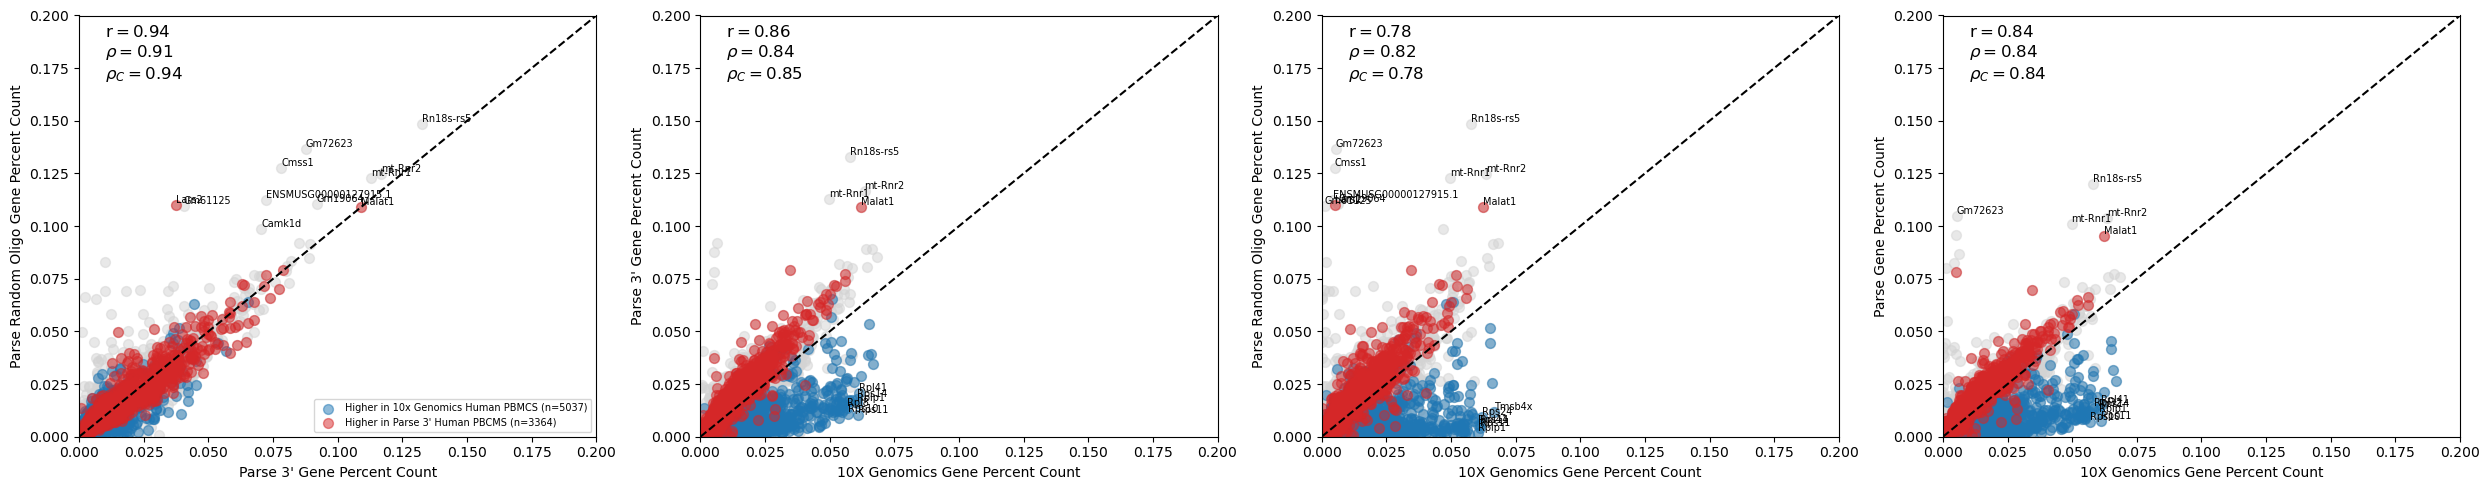

In [ ]:
results= pd.read_csv("/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvPolyT/results.csv")

plotting.compare_by_de(
    compare_dfs, comparisons, lim=lim,
    de_results=results,              # DataFrame from perform_edgepy
    de_comparing=("10x Genomics Human PBMCS", "Parse 3' Human PBCMS"),   # the two sides
    fdr_thresh=0.01,
)

  Parse 3' vs Parse Random Oligo | Higher in 10x Genomics Human PBMCS (n=6808): 2039/3914 toward Parse 3', 1875/3914 toward Parse Random Oligo
  Parse 3' vs Parse Random Oligo | Higher in Parse Human PBCMS (n=5772): 1157/2975 toward Parse 3', 1818/2975 toward Parse Random Oligo
  10X Genomics vs Parse 3' | Higher in 10x Genomics Human PBMCS (n=6808): 3060/3921 toward 10X Genomics, 861/3921 toward Parse 3'
  10X Genomics vs Parse 3' | Higher in Parse Human PBCMS (n=5772): 756/2971 toward 10X Genomics, 2215/2971 toward Parse 3'
  10X Genomics vs Parse Random Oligo | Higher in 10x Genomics Human PBMCS (n=6808): 2908/3918 toward 10X Genomics, 1010/3918 toward Parse Random Oligo
  10X Genomics vs Parse Random Oligo | Higher in Parse Human PBCMS (n=5772): 583/2967 toward 10X Genomics, 2384/2967 toward Parse Random Oligo
  10X Genomics vs Parse | Higher in 10x Genomics Human PBMCS (n=6808): 2886/3918 toward 10X Genomics, 1032/3918 toward Parse
  10X Genomics vs Parse | Higher in Parse Human P

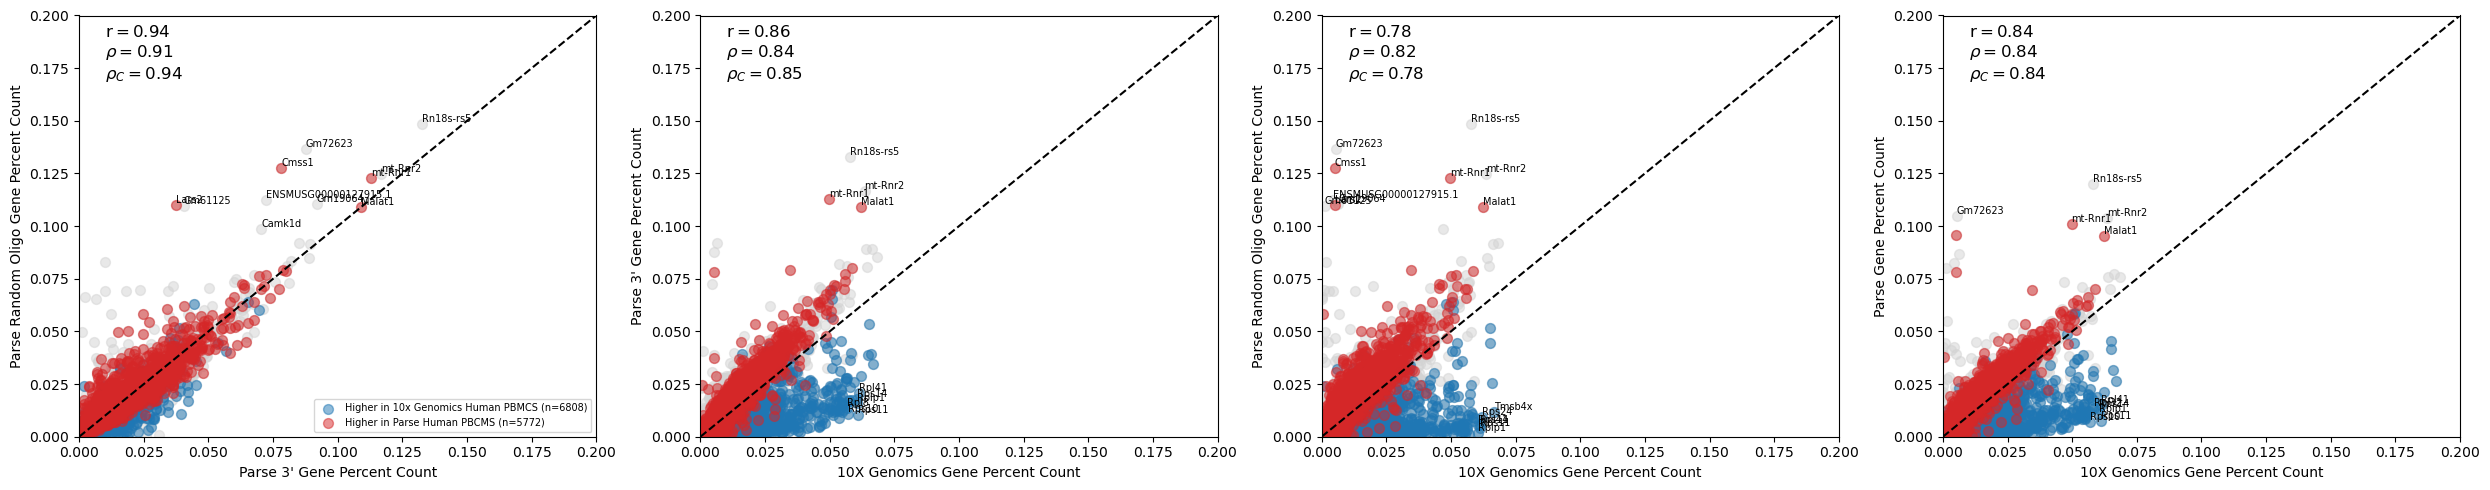

In [ ]:
results= pd.read_csv("/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/results.csv")

plotting.compare_by_de(
    compare_dfs, comparisons, lim=lim,
    de_results=results,              # DataFrame from perform_edgepy
    de_comparing=("10x Genomics Human PBMCS", "Parse Human PBCMS"),   # the two sides
    fdr_thresh=0.01,
)

  Parse 3' vs Parse Random Oligo | Higher in 10x Genomics Human PBMCS (n=7395): 3242/4107 toward Parse 3', 865/4107 toward Parse Random Oligo
  Parse 3' vs Parse Random Oligo | Higher in Parse Human PBCMS (n=7182): 826/4776 toward Parse 3', 3950/4776 toward Parse Random Oligo
  10X Genomics vs Parse 3' | Higher in 10x Genomics Human PBMCS (n=7395): 1635/4121 toward 10X Genomics, 2486/4121 toward Parse 3'
  10X Genomics vs Parse 3' | Higher in Parse Human PBCMS (n=7182): 2607/4764 toward 10X Genomics, 2157/4764 toward Parse 3'
  10X Genomics vs Parse Random Oligo | Higher in 10x Genomics Human PBMCS (n=7395): 2273/4119 toward 10X Genomics, 1846/4119 toward Parse Random Oligo
  10X Genomics vs Parse Random Oligo | Higher in Parse Human PBCMS (n=7182): 1516/4768 toward 10X Genomics, 3252/4768 toward Parse Random Oligo
  10X Genomics vs Parse | Higher in 10x Genomics Human PBMCS (n=7395): 1827/4124 toward 10X Genomics, 2297/4124 toward Parse
  10X Genomics vs Parse | Higher in Parse Human 

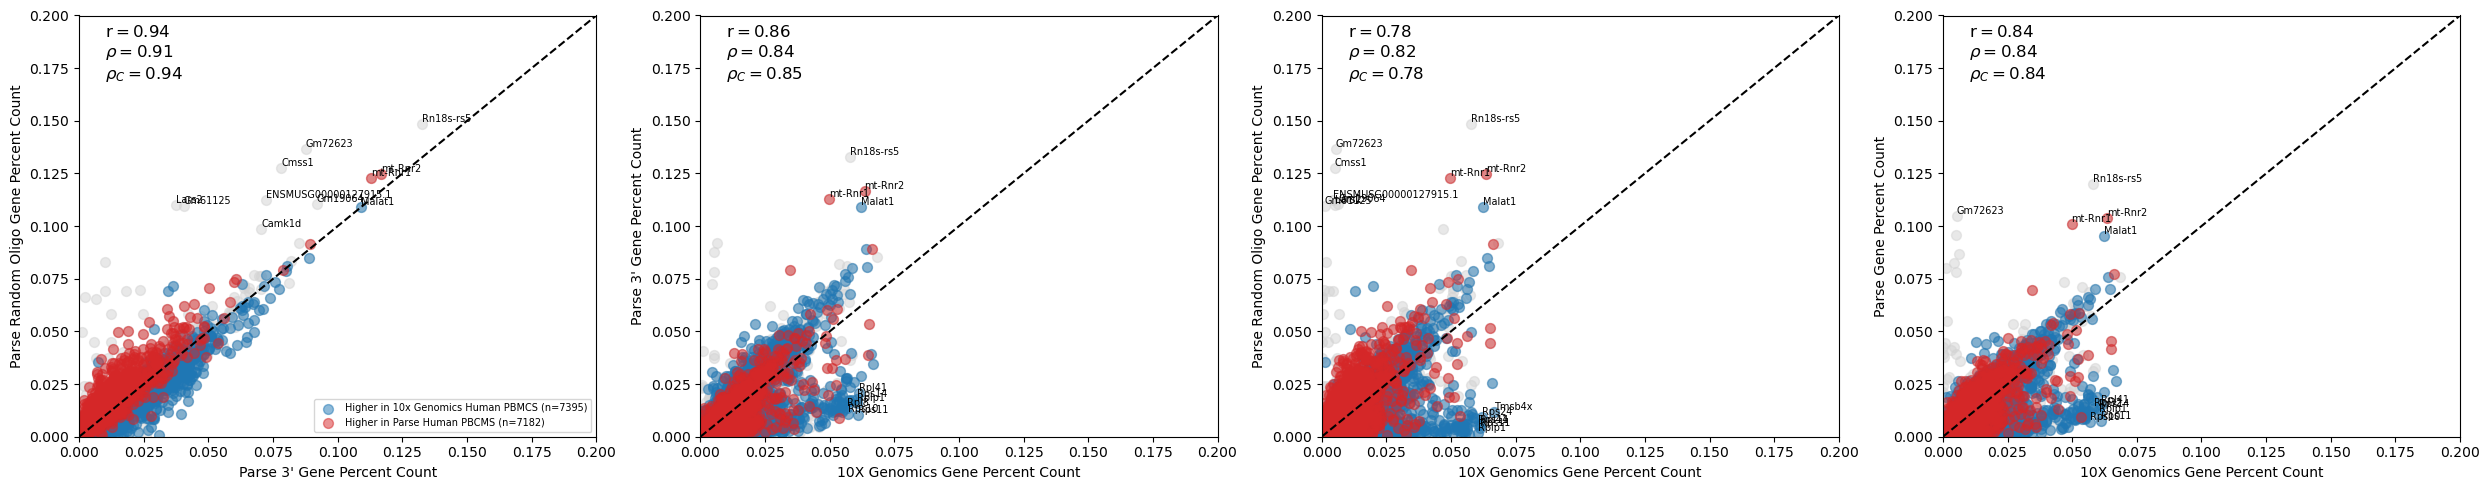

In [ ]:
results= pd.read_csv("/home/mcaskey/10XvParse/Notebooks/Comparisons/PolyTvRandO/results.csv")

plotting.compare_by_de(
    compare_dfs, comparisons, lim=lim,
    de_results=results,              # DataFrame from perform_edgepy
    de_comparing=("10x Genomics Human PBMCS", "Parse Human PBCMS"),   # the two sides
    fdr_thresh=0.01,
)

In [ ]:
for name, df in zip(compare_names, compare_dfs):
    gene_info = plotting.merge_by_cooks(gene_info, name, df)
gene_info.to_csv(FULL_GENE_INFO_PATH)